Setup and Configuration

In [ ]:
!pip install gymnasium


In [ ]:
import gymnasium as gym
import numpy as np
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import heapq
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import pickle
import os
from collections import defaultdict
from collections import Counter
import gc

In [ ]:
# --- Global Configurations ---
SEEDS = [42, 123, 777, 999, 2024]
EPISODES = 500

In [ ]:
EXPERIMENT_NAME = "baseline_sarsa_vs_ps"
RESULTS_FILE = f"results_{EXPERIMENT_NAME}.csv"

Agent Definition

In [ ]:
class SARSAAgent:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, use_prioritized_sweeping=False, use_kernel=False, seed=None, c =0.5, beta = 4, planning_steps = 5):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.action_space_size = env.action_space.n
        self.state_space_size = env.observation_space.n

        # --- Flags ---
        self.use_prioritized_sweeping = use_prioritized_sweeping
        self.use_kernel = use_kernel

        # --- Generalization (Kernel) Params ---
        self.c = c
        self.beta = beta

        self.q_table = np.zeros((self.state_space_size, self.action_space_size))
        self.rng = np.random.default_rng(seed)

        # --- PS Variables ---
        if self.use_prioritized_sweeping:
            self.theta = 1e-4
            self.planning_steps = planning_steps
            self.model = {}
            self.predecessors = {}
            self.pq = []


    def _get_kernel(self, s1, s2):
      r1, c1, p1, d1 = self.env.unwrapped.decode(s1)
      r2, c2, p2, d2 = self.env.unwrapped.decode(s2)

      # States are similar only if passenger status/location and destination match
      if p1 != p2 or d1 != d2:
          return 0.0

      dist = abs(r1 - r2) + abs(c1 - c2)
      return 1 / (1 + np.exp(self.beta * (dist - self.c)))


    def choose_action(self, state):
        # Epsilon-greedy action selection strategy
        if self.rng.random() < self.epsilon:
            # Explore: choose a random action using the seeded generator
            return self.rng.integers(self.action_space_size)
        else:
            # Exploit: choose the action with the highest Q-value for the current state
            return np.argmax(self.q_table[state])



    def update(self, state, action, reward, next_state, next_action, done):
        # 1. Standard SARSA TD target calculation
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.q_table[next_state][next_action]

        # Calculate TD error (the "surprise" factor)
        td_error = td_target - self.q_table[state][action]

        # 2. Q-table update
        # Always update the real current state-action pair normally
        self.q_table[state][action] += self.alpha * td_error

        # If kernel is enabled, also update similar states
        if self.use_kernel:
            for s_hat in range(self.state_space_size):
                if s_hat == state:
                    continue

                k = self._get_kernel(state, s_hat)

                if k > 0:
                    self.q_table[s_hat][action] += self.alpha * k * td_error

        # If Prioritized Sweeping is turned off, we are done here
        if not self.use_prioritized_sweeping:
            return

        # 3. Model & Predecessors Update
        # Store transition in the model
        self.model[(state, action)] = (reward, next_state, done)

        # Update predecessors (list of states leading to the next_state)
        if next_state not in self.predecessors:
            self.predecessors[next_state] = set()
        self.predecessors[next_state].add((state, action))

        # 4. Push to Priority Queue (only if significant surprise)
        priority = abs(td_error)
        if priority > self.theta:
            heapq.heappush(self.pq, (-priority, (state, action)))

        # 5. Planning Phase
        for _ in range(self.planning_steps):
            if not self.pq:
                break

            # Pop the most surprising state-action pair
            _, (s, a) = heapq.heappop(self.pq)
            r, s_next, is_done = self.model[(s, a)]

            # Calculate target for planning update
            if is_done:
                v_target = r
            else:
                next_a = self.choose_action(s_next)
                v_target = r + self.gamma * self.q_table[s_next][next_a]

            v_error = v_target - self.q_table[s][a]
            self.q_table[s][a] += self.alpha * v_error

            # Propagate backwards to predecessors
            if s in self.predecessors:
                for s_prev, a_prev in self.predecessors[s]:
                    r_prev, _, prev_is_done = self.model[(s_prev, a_prev)]

                    # Calculate target for predecessor
                    if prev_is_done:
                        pred_target = r_prev
                    else:
                        next_a_for_s = self.choose_action(s)
                        pred_target = r_prev + self.gamma * self.q_table[s][next_a_for_s]

                    pred_error = abs(pred_target - self.q_table[s_prev][a_prev])

                    # If predecessor is surprised enough, add to queue
                    if pred_error > self.theta:
                        heapq.heappush(self.pq, (-pred_error, (s_prev, a_prev)))


In [ ]:
class CustomTaxiRewardWrapper(gym.Wrapper):
    def __init__(self, env, reward_type="base", params=None):
        super().__init__(env)
        self.reward_type = reward_type
        self.params = params if params is not None else {}
        self.locs = [(0,0), (0,4), (4,0), (4,3)]
        self.was_in_taxi = False
        self.prev_dist = 0

    def _get_distance(self, state):
        taxi_row, taxi_col, pass_loc, dest_idx = self.env.unwrapped.decode(state)
        if pass_loc < 4:
            target_row, target_col = self.locs[pass_loc]
        else:
            target_row, target_col = self.locs[dest_idx]
        return abs(taxi_row - target_row) + abs(taxi_col - target_col)

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        _, _, pass_loc, _ = self.env.unwrapped.decode(state)
        self.was_in_taxi = (pass_loc == 4)
        self.prev_dist = self._get_distance(state)
        return state, info

    def step(self, action):
        next_state, base_reward, terminated, truncated, info = self.env.step(action)
        _, _, pass_loc, _ = self.env.unwrapped.decode(next_state)

        is_in_taxi = (pass_loc == 4)
        curr_dist = self._get_distance(next_state)

        successful_pickup = (not self.was_in_taxi) and is_in_taxi and (action == 4)
        successful_dropoff = (base_reward == 20)
        illegal_action = (base_reward == -10)

        info['is_error'] = illegal_action

        custom_reward = base_reward

        if self.reward_type == "sparse":
            if successful_dropoff or successful_pickup:
                custom_reward = 0.5
            else:
                custom_reward = 0.0

        elif self.reward_type == "reward3":
            if successful_dropoff: custom_reward = self.params.get("dropoff", 10.0)
            elif successful_pickup: custom_reward = self.params.get("pickup", 2.0)
            elif illegal_action: custom_reward = self.params.get("illegal", -3.0)
            else: custom_reward = self.params.get("step", -1.0)

        elif self.reward_type == "reward4":
            if successful_dropoff: custom_reward = self.params.get("dropoff", 20.0)
            elif successful_pickup: custom_reward = self.params.get("pickup", 10.0)
            elif illegal_action: custom_reward = self.params.get("illegal", -10.0)
            else:
                if curr_dist < self.prev_dist: custom_reward = self.params.get("closer", 1.0)
                elif curr_dist > self.prev_dist: custom_reward = self.params.get("further", -2.0)
                else: custom_reward = self.params.get("neutral", -1.0)

        self.was_in_taxi = is_in_taxi
        self.prev_dist = curr_dist

        return next_state, custom_reward, terminated, truncated, info

Global training function

In [ ]:
def run_universal_training(
    reward_type="base",
    reward_params=None,
    use_ps=False,
    use_kernel=False,
    episodes=500,
    seed=42,
    max_steps=200,
    desc="Training",
    alpha=0.1,
    gamma=0.99,
    epsilon=0.1,
    planning_steps=5,
    c=0.5,
    beta=4
):
    """
    A universal training function that handles all types of experiments.
    Returns the trained agent and history metrics (rewards, steps, errors).
    """
    # 1. Environment Setup
    base_env = gym.make("Taxi-v4", is_rainy=False)

    env = CustomTaxiRewardWrapper(base_env, reward_type=reward_type, params=reward_params)
#    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, use_prioritized_sweeping=False, use_kernel=False, seed=None, c =0.5, beta = 4, planning_steps = 5):

    # 2. Agent Setup
    agent = SARSAAgent(
        env,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        use_prioritized_sweeping=use_ps,
        use_kernel=use_kernel,
        seed=seed,
        c=c,
        beta=beta,
        planning_steps=planning_steps,

    )

    # 3. Metrics Tracking
    rewards_history = []
    steps_history = []
    errors_history = []
    success_history = []

    # 4. Training Loop
    for ep in tqdm(range(episodes), desc=f"{desc} (Seed {seed})"):
        state, _ = env.reset(seed=seed + ep)

        action = agent.choose_action(state)

        done = False
        steps = 0
        ep_reward = 0
        ep_errors = 0
        success = 0

        while not done and steps < max_steps:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if terminated:
                success = 1

            if info.get('is_error', False):
                ep_errors += 1

            if done:
                next_action = 0 # Dummy action
            else:
                next_action = agent.choose_action(next_state)

            agent.update(state, action, reward, next_state, next_action, done)

            state, action = next_state, next_action

            steps += 1
            ep_reward += reward

        rewards_history.append(ep_reward)
        steps_history.append(steps)
        errors_history.append(ep_errors)
        success_history.append(success)

    return agent, rewards_history, steps_history, errors_history, success_history

Experiment Execution and Data Saving

In [ ]:
# Check if we already ran the experiments
if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}...")
    data = pd.read_csv(RESULTS_FILE)
else:
    print(f"No existing results found. Starting training over all seeds for {EXPERIMENT_NAME}...")
    all_data = []

    for seed in SEEDS:
        print(f"\n--- Training for Seed: {seed} ---")

        # 1. Train Base SARSA (No PS)
        agent_sarsa, rewards_sarsa, steps_sarsa, errors_sarsa, _ = run_universal_training(
            reward_type="base",
            use_ps=False,
            episodes=EPISODES,
            seed=seed,
            desc="Base SARSA"
        )

        for ep in range(EPISODES):
            all_data.append({
                'Seed': seed, 'Episode': ep,
                'Reward': rewards_sarsa[ep],
                'Steps': steps_sarsa[ep],
                'Errors': errors_sarsa[ep],
                'Algorithm': 'SARSA'
            })

        # 2. Train SARSA + PS
        agent_ps, rewards_ps, steps_ps, errors_ps, _ = run_universal_training(
            reward_type="base",
            use_ps=True,        # SARSA + Prioritized Sweeping
            episodes=EPISODES,
            seed=seed,
            desc="SARSA + PS"
        )

        for ep in range(EPISODES):
            all_data.append({
                'Seed': seed, 'Episode': ep,
                'Reward': rewards_ps[ep],
                'Steps': steps_ps[ep],
                'Errors': errors_ps[ep],
                'Algorithm': 'SARSA + PS'
            })

    # Save results to CSV for future runs
    data = pd.DataFrame(all_data)
    data.to_csv(RESULTS_FILE, index=False)
    print(f"\nTraining finished! Results saved to {RESULTS_FILE}")

Loading existing results from results_baseline_sarsa_vs_ps.csv...


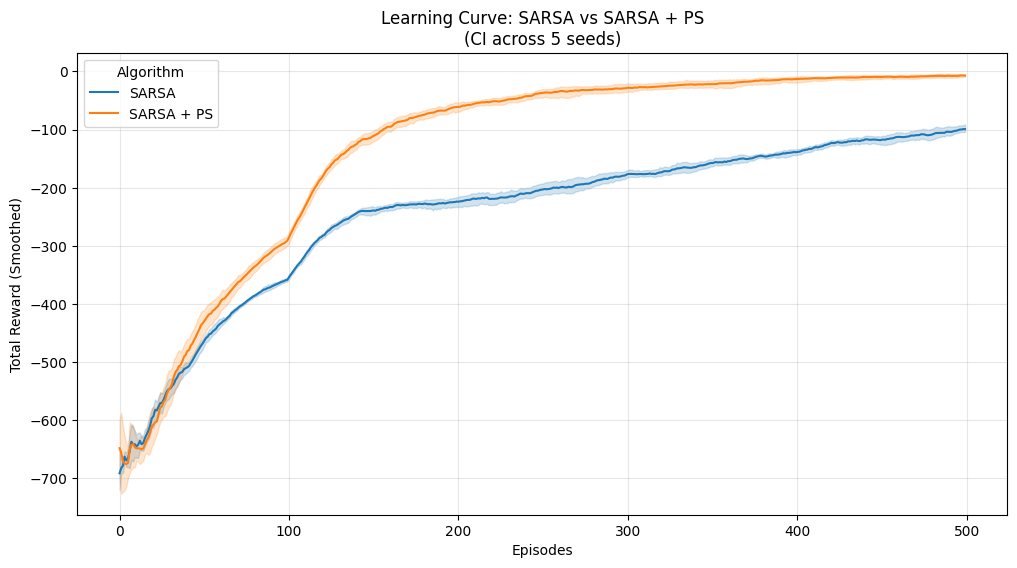

In [ ]:
# Apply rolling mean for smoothing, grouping by both Algorithm and Seed
data['Smoothed_Reward'] = data.groupby(['Algorithm', 'Seed'])['Reward'].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

# Plot with Seaborn
plt.figure(figsize=(12, 6))

# Use lineplot with explicit 95% Confidence Interval across the 5 seeds
sns.lineplot(
    data=data,
    x='Episode',
    y='Smoothed_Reward',
    hue='Algorithm',
    errorbar=('ci', 95)
)

# Adding the exact info to the title so the grader sees it immediately
plt.title(f"Learning Curve: SARSA vs SARSA + PS\n(CI across {len(SEEDS)} seeds)")
plt.ylabel("Total Reward (Smoothed)")
plt.xlabel("Episodes")
plt.grid(True, alpha=0.3)
plt.show()

Comparison against all possible options

In [ ]:
EXPERIMENT_NAME = "ablation_study"
RESULTS_FILE = f"results_{EXPERIMENT_NAME}.csv"

# Configuration for experiments
configs = [
    {"name": "Base SARSA", "ps": False, "kernel": False},
    {"name": "SARSA + PS", "ps": True, "kernel": False},
    {"name": "SARSA + Kernel", "ps": False, "kernel": True},
    {"name": "SARSA + PS + Kernel", "ps": True, "kernel": True}
]

# Check if we already ran the experiments
if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}...")
    df = pd.read_csv(RESULTS_FILE)
else:
    print(f"No existing results found. Starting training over all seeds for {EXPERIMENT_NAME}...")
    all_data = []

    for config in configs:
        print(f"\n--- Training Configuration: {config['name']} ---")

        for seed in SEEDS:
            _, rewards, steps, errors, _ = run_universal_training(
                reward_type="base",
                use_ps=config['ps'],
                use_kernel=config['kernel'],
                episodes=EPISODES,
                seed=seed,
                desc=config['name']
            )

            # Store results
            for ep in range(EPISODES):
                all_data.append({
                    'Seed': seed,
                    'Episode': ep,
                    'Reward': rewards[ep],
                    'Steps': steps[ep],
                    'Errors': errors[ep],
                    'Algorithm': config['name']
                })

    # Save results to CSV for future runs
    df = pd.DataFrame(all_data)
    df.to_csv(RESULTS_FILE, index=False)
    print(f"\nTraining finished! Results saved to {RESULTS_FILE}")

Loading existing results from results_ablation_study.csv...


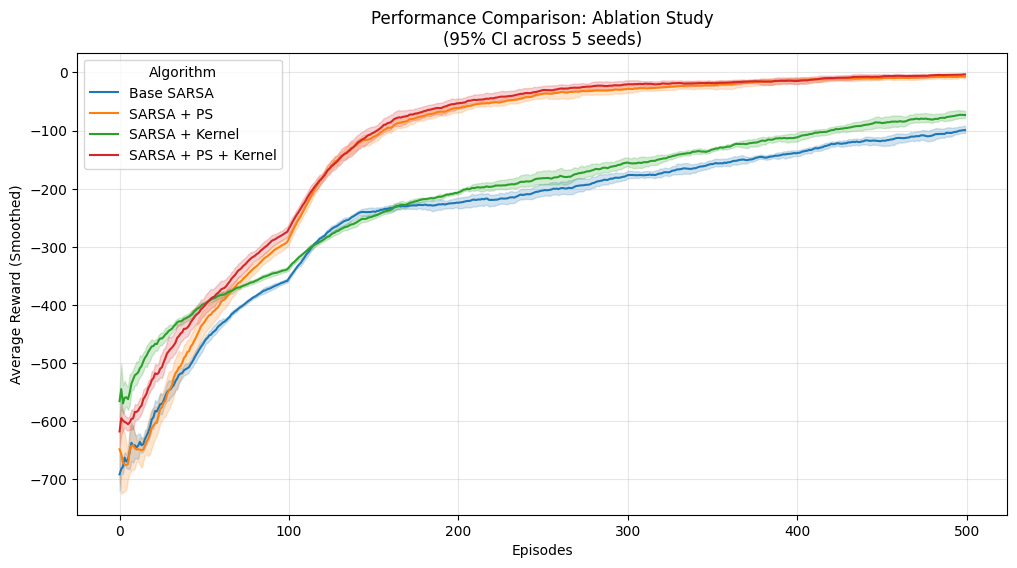

In [ ]:
# Apply rolling mean for smoothing, grouping by both Algorithm and Seed
df['Smoothed_Reward'] = df.groupby(['Algorithm', 'Seed'])['Reward'].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

# Plot with Seaborn
plt.figure(figsize=(12, 6))

# Use lineplot with explicit 95% Confidence Interval across the 5 seeds
sns.lineplot(
    data=df,
    x='Episode',
    y='Smoothed_Reward',
    hue='Algorithm',
    errorbar=('ci', 95)
)

plt.title(f"Performance Comparison: Ablation Study\n(95% CI across {len(SEEDS)} seeds)")
plt.ylabel("Average Reward (Smoothed)")
plt.xlabel("Episodes")
plt.grid(True, alpha=0.3)
plt.show()

Reward Designs:
1. Base
2. Sparse - +0.5 for successful
dropoff and +0.5 for successful pickup
3. Reward 3 - milestone rewards - 4 versions
4. Reward 4 - distance-based - 4 versions

In [ ]:
EXPERIMENT_NAME = "mega_reward_experiment"
RESULTS_FILE = f"results_{EXPERIMENT_NAME}.csv"

EPISODES = 500

configurations = [
    {"label": "Base Reward", "type": "base", "params": {}},
    {"label": "Sparse Reward", "type": "sparse", "params": {}},

    # Reward 3
    {"label": "R3_V1 (20, 5, -10, -1)", "type": "reward3", "params": {"dropoff": 20.0, "pickup": 5.0, "illegal": -10.0, "step": -1.0}},
    {"label": "R3_V2 (10, 2, -3, -2)",  "type": "reward3", "params": {"dropoff": 10.0, "pickup": 2.0, "illegal": -3.0, "step": -2.0}},
    {"label": "R3_V3 (10, 2, -3, -1)",  "type": "reward3", "params": {"dropoff": 10.0, "pickup": 2.0, "illegal": -3.0, "step": -1.0}},
    {"label": "R3_V4 (10, 2, -3, -0.5)","type": "reward3", "params": {"dropoff": 10.0, "pickup": 3.0, "illegal": -7.0, "step": -1}},

    # Reward 4
    {"label": "R4_V1 (60,15,-25,  0.5,-2,-1)", "type": "reward4", "params": {"dropoff": 60.0, "pickup": 15.0, "illegal": -25.0, "closer": 0.5, "further": -2.0, "neutral": -1.0}},
    {"label": "R4_V2 (80,20,-15,  1,-1.5,-1)", "type": "reward4", "params": {"dropoff": 80.0, "pickup": 20.0, "illegal": -15.0, "closer": 1.0, "further": -1.5, "neutral": -1.0}},
    {"label": "R4_V3 (60,15,-25,  1,-2,-1)",   "type": "reward4", "params": {"dropoff": 60.0, "pickup": 15.0, "illegal": -25.0, "closer": 1.0, "further": -2.0, "neutral": -1.0}},
    {"label": "R4_V4 (40,20,-25,  2,-5,-1)",   "type": "reward4", "params": {"dropoff": 40.0, "pickup": 20.0, "illegal": -25.0, "closer": 2.0, "further": -5.0, "neutral": -1.0}}
]

# Check if we already ran the experiments
if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}...")
    df = pd.read_csv(RESULTS_FILE)
else:
    print("Starting mega-experiment...")
    all_results = []

    for config in configurations:
        print(f"\n--- Training configuration: {config['label']} ---")

        for seed in SEEDS:
            _, rewards, steps, errors, _ = run_universal_training(
                reward_type=config['type'],
                reward_params=config['params'],
                use_ps=True,
                episodes=EPISODES,
                seed=seed,
                desc=config['label']
            )

            for ep in range(EPISODES):
                all_results.append({
                    "Configuration": config['label'],
                    "Seed": seed,
                    "Episode": ep,
                    "Reward": rewards[ep],
                    "Steps": steps[ep],
                    "Errors": errors[ep]
                })

    df = pd.DataFrame(all_results)
    df.to_csv(RESULTS_FILE, index=False)
    print(f"\nAll done! Results saved to '{RESULTS_FILE}'")

Loading existing results from results_mega_reward_experiment.csv...


Found 8 custom reward variants.
Generating sets of comparison plots...



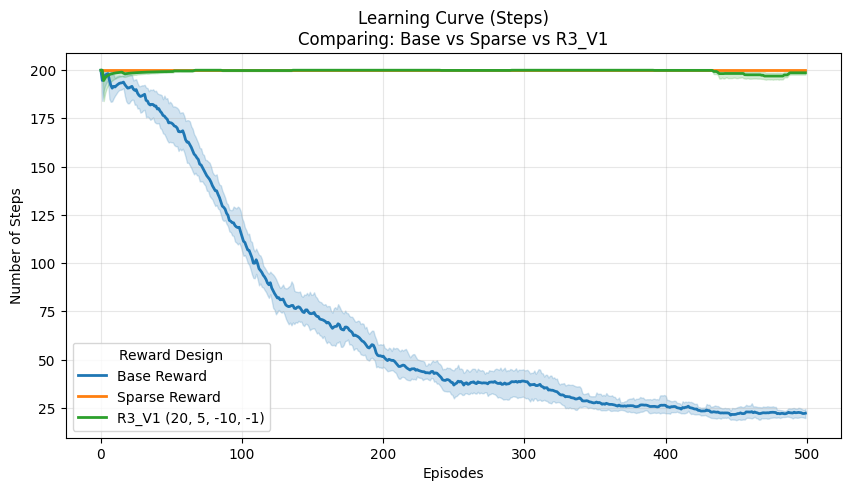

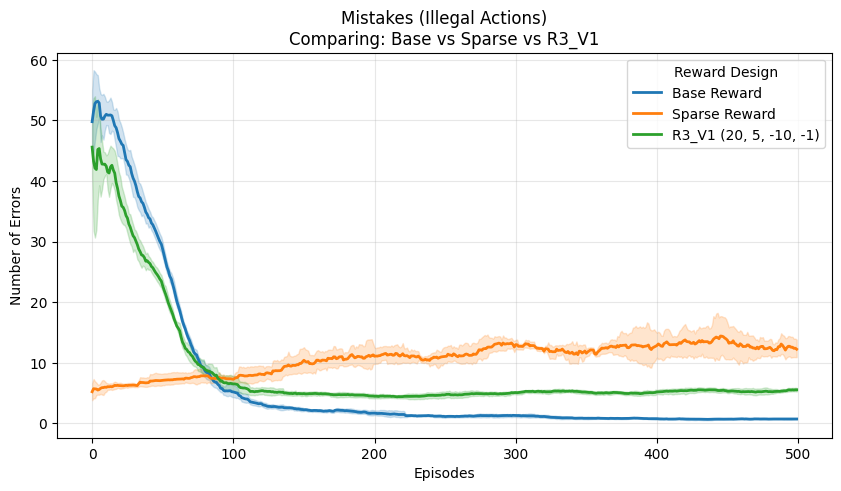

--------------------------------------------------------------------------------


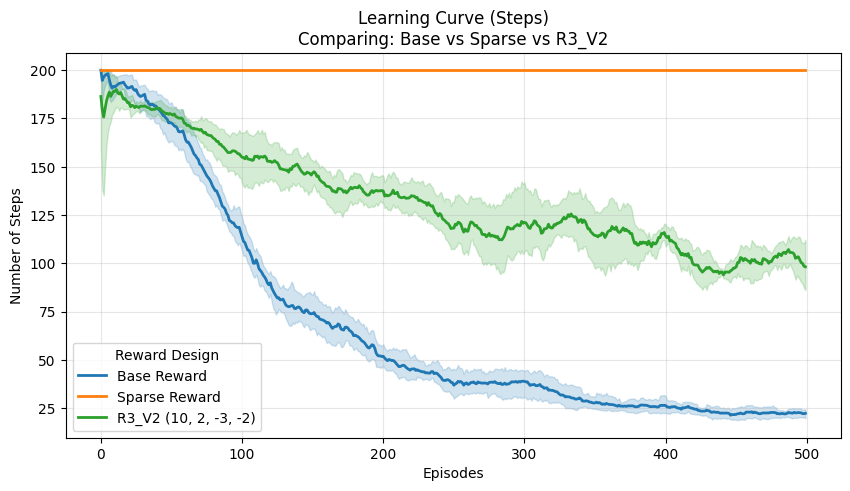

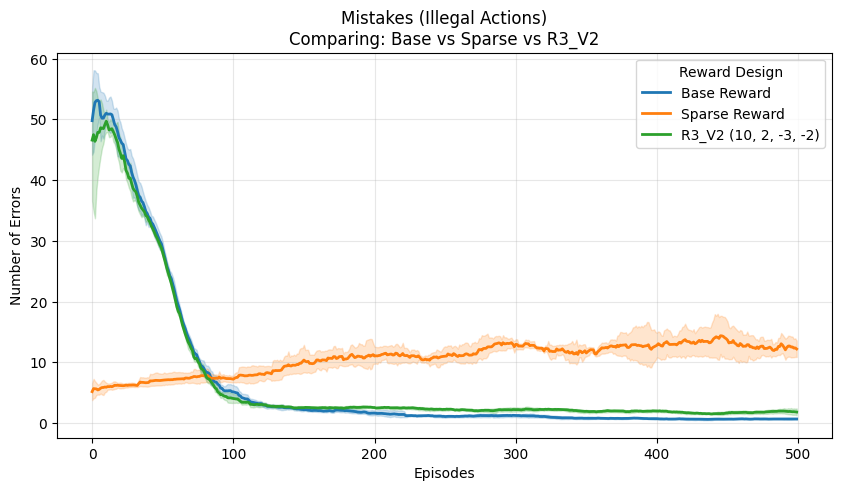

--------------------------------------------------------------------------------


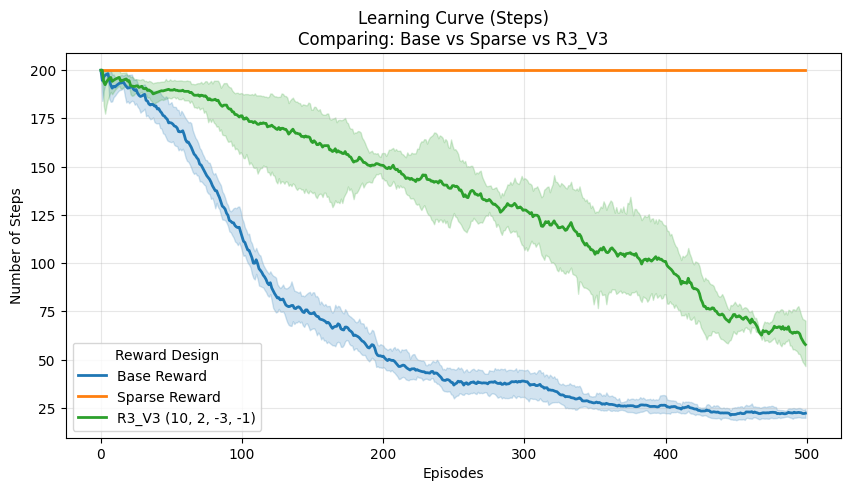

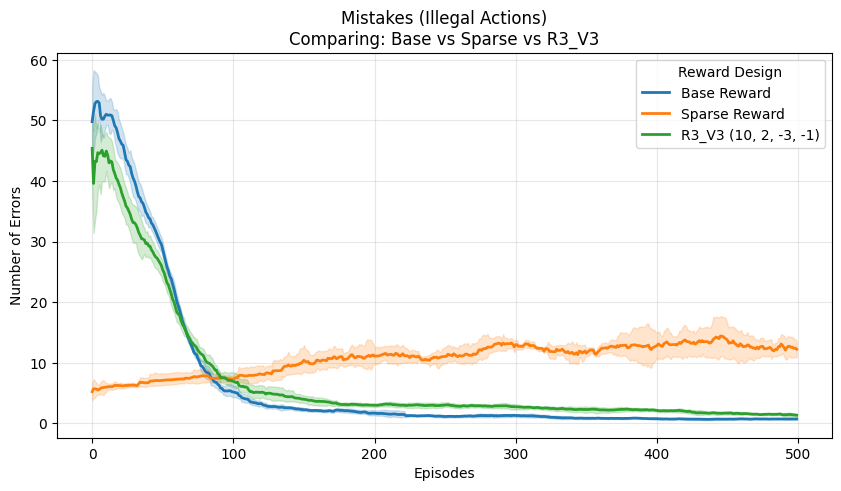

--------------------------------------------------------------------------------


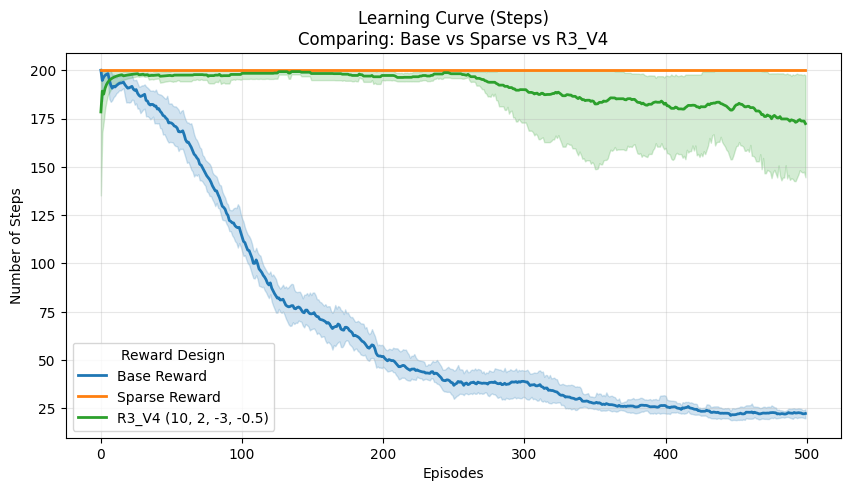

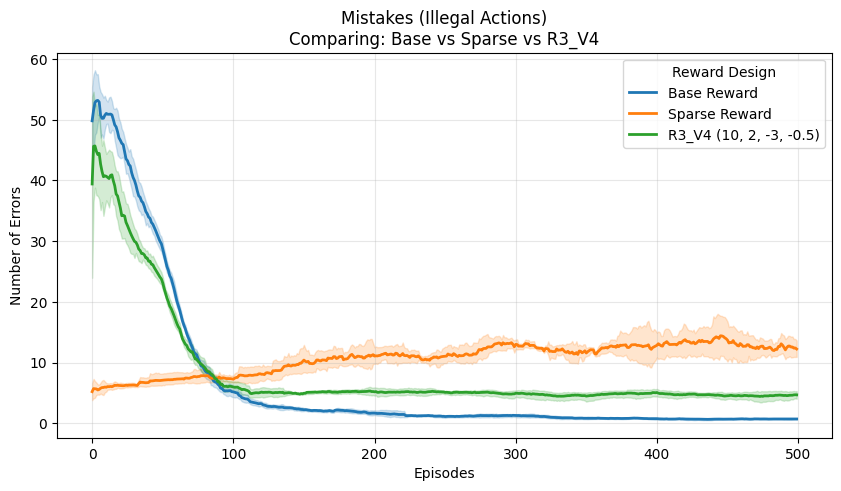

--------------------------------------------------------------------------------


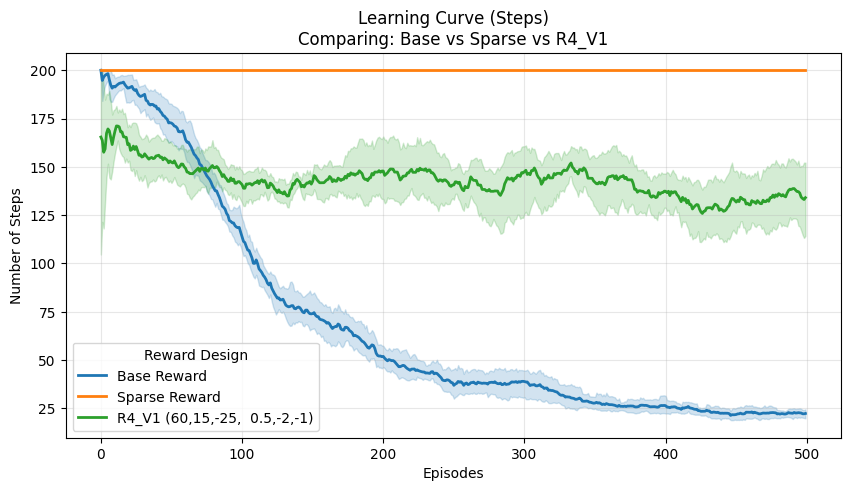

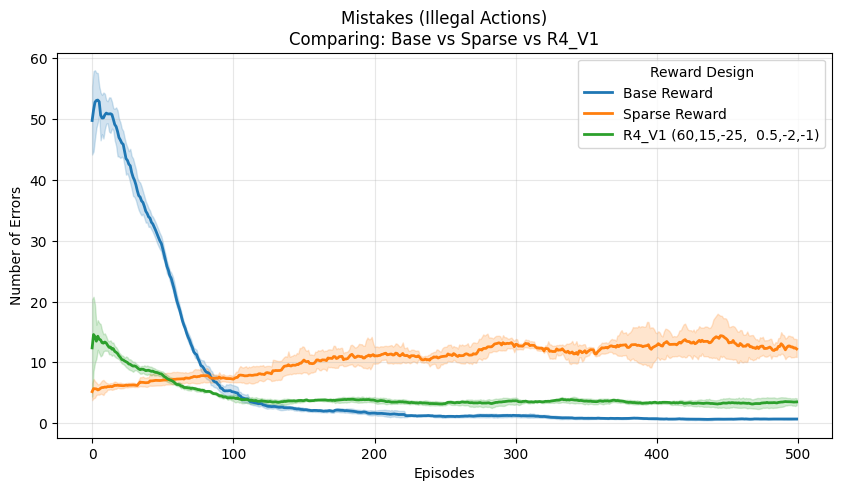

--------------------------------------------------------------------------------


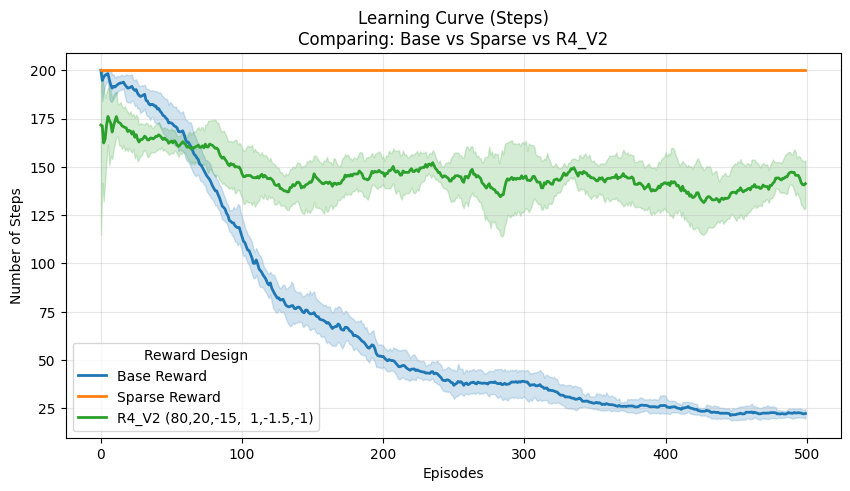

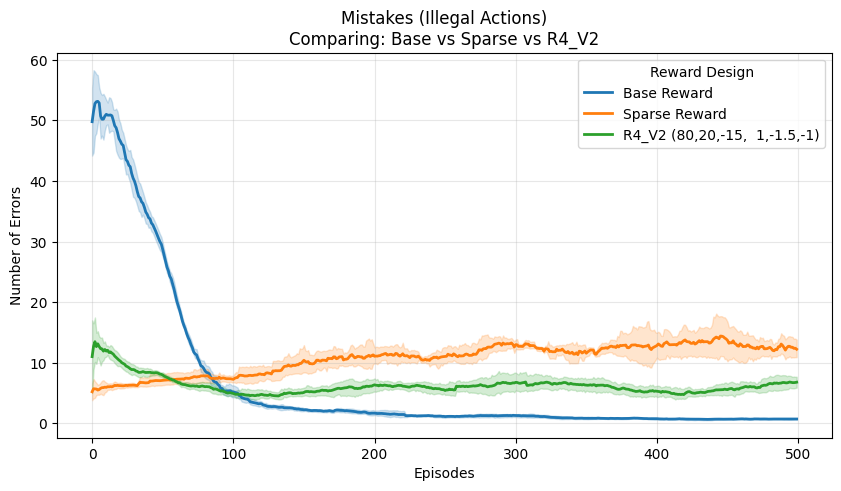

--------------------------------------------------------------------------------


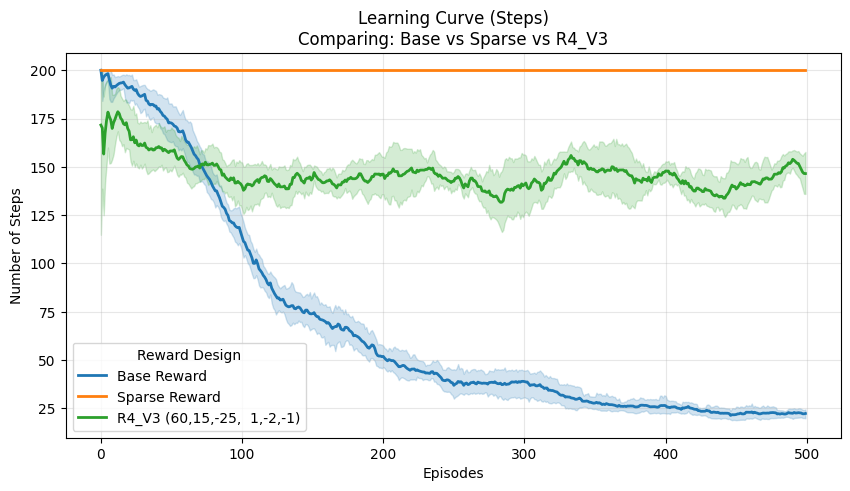

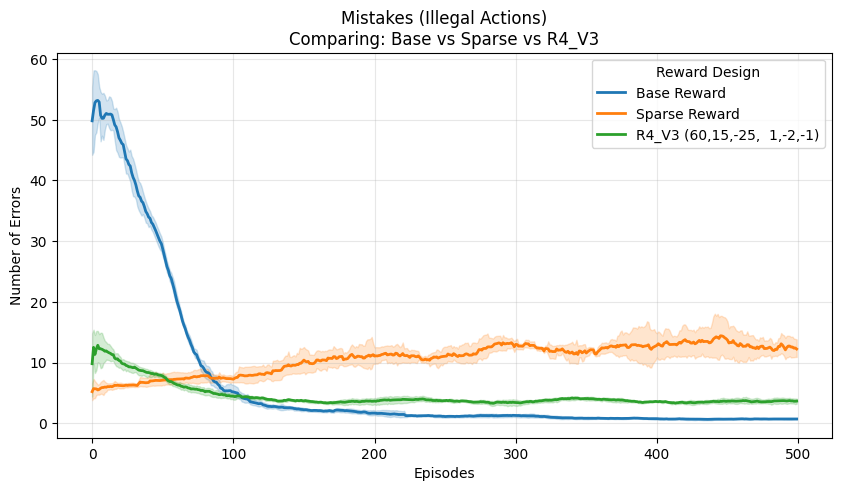

--------------------------------------------------------------------------------


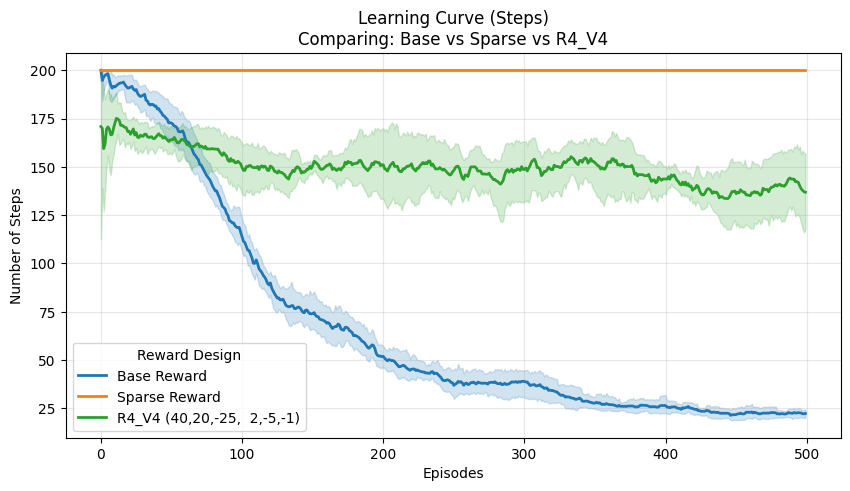

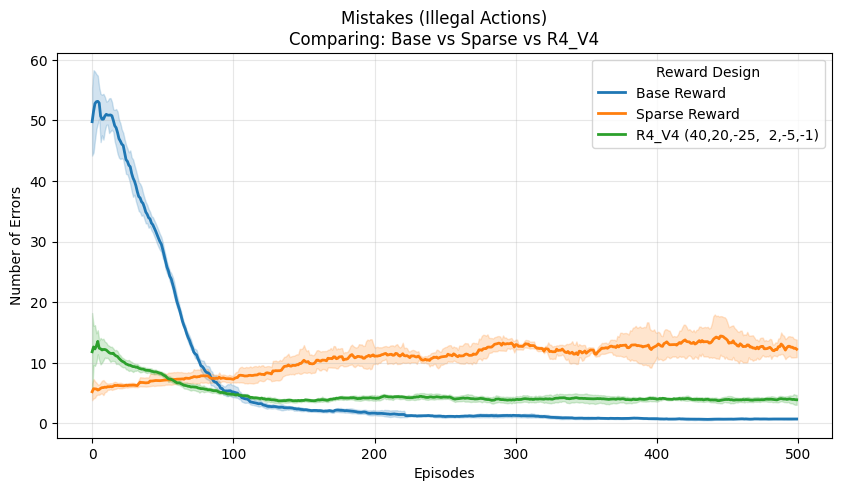

--------------------------------------------------------------------------------


In [ ]:
WINDOW_SIZE = 50

# Apply smoothing
df['Smoothed_Steps'] = df.groupby(['Configuration', 'Seed'])['Steps'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)
df['Smoothed_Errors'] = df.groupby(['Configuration', 'Seed'])['Errors'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)

base_sparse = ["Base Reward", "Sparse Reward"]
custom_variants = [config for config in df['Configuration'].unique() if config.startswith("R3") or config.startswith("R4")]

print(f"Found {len(custom_variants)} custom reward variants.")
print("Generating sets of comparison plots...\n")

for variant in custom_variants:
    current_configs = base_sparse + [variant]
    df_subset = df[df['Configuration'].isin(current_configs)]
    variant_short_name = variant.split()[0]

    # --- Plot 1: Steps per Episode ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=df_subset,
        x="Episode",
        y="Smoothed_Steps",
        hue="Configuration",
        errorbar=("ci", 95),
        linewidth=2
    )
    plt.title(f"Learning Curve (Steps)\nComparing: Base vs Sparse vs {variant_short_name}")
    plt.xlabel("Episodes")
    plt.ylabel("Number of Steps")
    plt.legend(title="Reward Design")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Plot 2: Errors per Episode ---
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=df_subset,
        x="Episode",
        y="Smoothed_Errors",
        hue="Configuration",
        errorbar=("ci", 95),
        linewidth=2
    )
    plt.title(f"Mistakes (Illegal Actions)\nComparing: Base vs Sparse vs {variant_short_name}")
    plt.xlabel("Episodes")
    plt.ylabel("Number of Errors")
    plt.legend(title="Reward Design")
    plt.grid(True, alpha=0.3)
    plt.show()

    print("-" * 80)

Final results graph - the best versions of reward 3 and 4

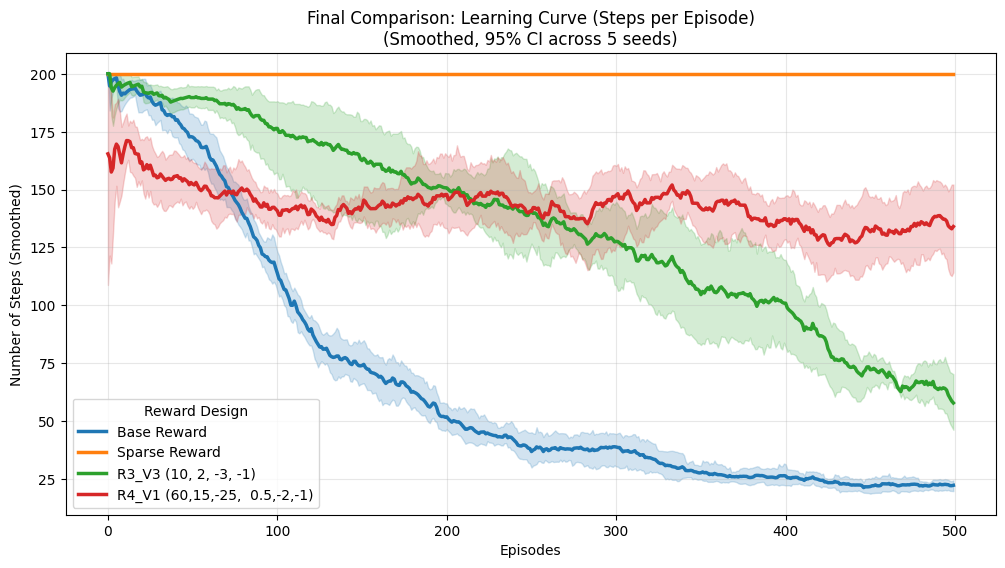

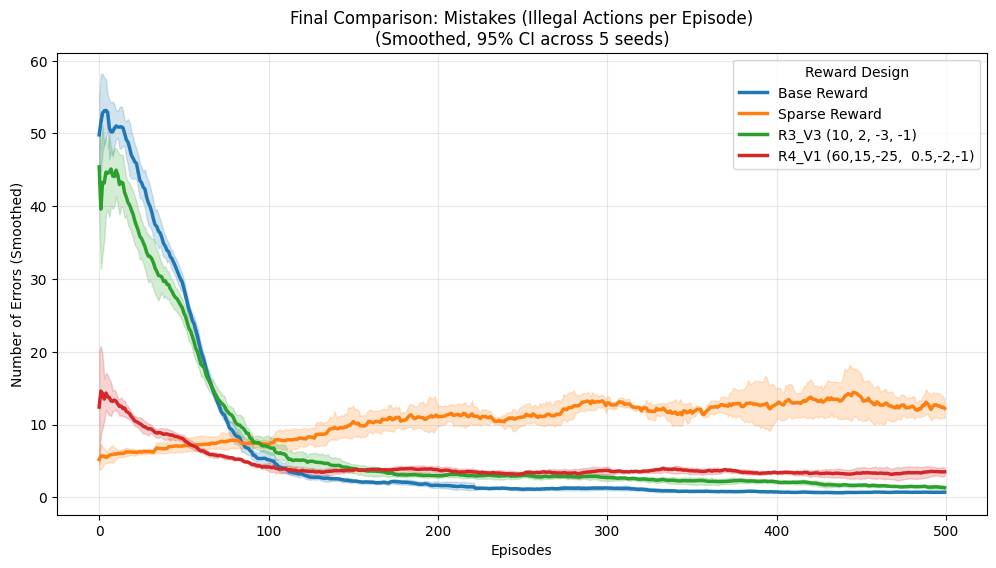

In [ ]:
df = pd.read_csv("results_mega_reward_experiment.csv")

WINDOW_SIZE = 50

# Apply smoothing
df['Smoothed_Steps'] = df.groupby(['Configuration', 'Seed'])['Steps'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)
df['Smoothed_Errors'] = df.groupby(['Configuration', 'Seed'])['Errors'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)

final_configs = [
    "Base Reward",
    "Sparse Reward",
    "R3_V3 (10, 2, -3, -1)",
    "R4_V1 (60,15,-25,  0.5,-2,-1)"
]

df_final = df[df['Configuration'].isin(final_configs)]

# --- Plot 1: Final Comparison (Steps) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_final,
    x="Episode",
    y="Smoothed_Steps",
    hue="Configuration",
    errorbar=("ci", 95),
    linewidth=2.5
)
plt.title(f"Final Comparison: Learning Curve (Steps per Episode)\n(Smoothed, 95% CI across {len(SEEDS)} seeds)")
plt.xlabel("Episodes")
plt.ylabel("Number of Steps (Smoothed)")
plt.legend(title="Reward Design")
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: Final Comparison (Errors) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_final,
    x="Episode",
    y="Smoothed_Errors",
    hue="Configuration",
    errorbar=("ci", 95),
    linewidth=2.5
)
plt.title(f"Final Comparison: Mistakes (Illegal Actions per Episode)\n(Smoothed, 95% CI across {len(SEEDS)} seeds)")
plt.xlabel("Episodes")
plt.ylabel("Number of Errors (Smoothed)")
plt.legend(title="Reward Design")
plt.grid(True, alpha=0.3)
plt.show()

Here we tried running the different reward functions and generating GIFs. Here we encountered a phenomenon where Reward 3 and Reward 4 do not terminate (i.e., they fail to reach the goal state)

In [ ]:
winners = [
    {"name": "Base Reward", "type": "base", "params": {}},
    {"name": "Reward 3 (V3)", "type": "reward3", "params": {"dropoff": 10.0, "pickup": 2.0, "illegal": -3.0, "step": -1.0}},
    {"name": "Reward 4 (V1)", "type": "reward4", "params": {"dropoff": 60.0, "pickup": 15.0, "illegal": -25.0, "closer": 0.5, "further": -2.0, "neutral": -1.0}}
]

trained_agents = {}
EPISODES_FOR_GIF = 1000

print("Starting training phase for GIFs...")

for w in winners:
    agent, _, _, _, _ = run_universal_training(
        reward_type=w['type'],
        reward_params=w['params'],
        use_ps=True,
        episodes=EPISODES_FOR_GIF,
        seed=42,
        desc=f"Training {w['name']}"
    )

    trained_agents[w['name']] = {
        "agent": agent,
        "type": w['type'],
        "params": w['params']
    }

print("\nTraining complete! Agents are saved in memory and ready for GIFs.")

Starting training phase for GIFs...


Training Reward 4 (V1) (Seed 42): 100%|██████████| 1000/1000 [00:46<00:00, 21.66it/s]


Training complete! Agents are saved in memory and ready for GIFs.


In [ ]:
def record_gif_from_trained_agent(agent, config_name, reward_type, params, filename, test_seed=42):
    print(f"Recording GIF for: {config_name}...")

    test_env_base = gym.make("Taxi-v4", render_mode="rgb_array", is_rainy=False)
    test_env = CustomTaxiRewardWrapper(test_env_base, reward_type=reward_type, params=params)

    state, _ = test_env.reset(seed=test_seed)
    done = False
    frames = []

    frames.append(Image.fromarray(test_env.render()))

    steps = 0

    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    while not done and steps < 200:
        action = agent.choose_action(state)
        state, _, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated

        frames.append(Image.fromarray(test_env.render()))
        steps += 1

    agent.epsilon = original_epsilon

    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=300,
        loop=0
    )
    print(f"Done! Saved '{filename}' (Episode finished in {steps} steps).")


print("Starting GIF generation...")

TEST_SEED = 70

for name, data in trained_agents.items():
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    filename = f"gif_{clean_name}.gif"

    record_gif_from_trained_agent(
        agent=data["agent"],
        config_name=name,
        reward_type=data["type"],
        params=data["params"],
        filename=filename,
        test_seed=TEST_SEED
    )

print("\nAll GIFs have been generated successfully!")

Starting GIF generation...
Recording GIF for: Base Reward...
Done! Saved 'gif_base_reward.gif' (Episode finished in 13 steps).
Recording GIF for: Reward 3 (V3)...
Done! Saved 'gif_reward_3_v3.gif' (Episode finished in 200 steps).
Recording GIF for: Reward 4 (V1)...
Done! Saved 'gif_reward_4_v1.gif' (Episode finished in 200 steps).

All GIFs have been generated successfully!


Reward 3 investigation


In [ ]:
# Function to evaluate a SINGLE agent greedly/epsilon-greedly
def evaluate_single_agent(agent, env_name, reward_type, params, num_episodes=100, seed=42, epsilon=0.0):
    test_env_base = gym.make(env_name, is_rainy=False)
    test_env = CustomTaxiRewardWrapper(test_env_base, reward_type=reward_type, params=params)

    # Force specific epsilon for testing
    original_epsilon = agent.epsilon
    agent.epsilon = epsilon

    successes = 0
    total_steps = 0

    for ep in range(num_episodes):
        state, _ = test_env.reset(seed=seed + ep)
        done = False
        steps = 0

        while not done and steps < 200:
            action = agent.choose_action(state)
            state, _, terminated, truncated, _ = test_env.step(action)
            done = terminated or truncated
            steps += 1

            if terminated:
                successes += 1

        total_steps += steps

    # Restore original epsilon just in case
    agent.epsilon = original_epsilon

    return (successes / num_episodes) * 100, total_steps / num_episodes

# Wrapper function to evaluate MULTIPLE agents and average the results
def evaluate_multiple_agents(agents_list, env_name, reward_type, params, num_episodes=100, epsilon=0.0):
    print(f"\nEvaluating {len(agents_list)} agents over {num_episodes} episodes each (ε={epsilon})...")

    all_success_rates = []
    all_avg_steps = []

    for i, agent in enumerate(agents_list):
        rate, steps = evaluate_single_agent(agent, env_name, reward_type, params, num_episodes, seed=9999+i, epsilon=epsilon)
        all_success_rates.append(rate)
        all_avg_steps.append(steps)

    avg_success_rate = np.mean(all_success_rates)
    avg_total_steps = np.mean(all_avg_steps)

    print("--- Evaluation Complete ---")
    print(f"Epsilon used: {epsilon}")
    print(f"Average Success Rate across all seeds: {avg_success_rate:.2f}%")
    print(f"Average Steps per Episode across all seeds: {avg_total_steps:.2f}")

    return avg_success_rate, avg_total_steps

Success Rate Evaluation

In [ ]:
print("--- Phase 1: Training Reward 3 for 500 Episodes (5 Seeds) ---")

params_r3 = {"dropoff": 10.0, "pickup": 2.0, "illegal": -3.0, "step": -1.0}
agents_500 = []

for seed in SEEDS:
    agent, _, _, _, _ = run_universal_training(
        reward_type="reward3",
        reward_params=params_r3,
        use_ps=True,
        episodes=500,
        seed=seed,
        desc=f"Seed {seed}"
    )
    agents_500.append(agent)

print("\n--- Testing Phase 1 Agents ---")
# 1. Test strictly greedy (epsilon = 0.0)
_ = evaluate_multiple_agents(agents_500, "Taxi-v4", "reward3", params_r3, num_episodes=100, epsilon=0.0)

# 2. Test with exploration (epsilon = 0.1) on the EXACT SAME AGENTS
_ = evaluate_multiple_agents(agents_500, "Taxi-v4", "reward3", params_r3, num_episodes=100, epsilon=0.1)

--- Phase 1: Training Reward 3 for 500 Episodes (5 Seeds) ---


Seed 2024 (Seed 2024): 100%|██████████| 500/500 [00:20<00:00, 24.71it/s]



--- Testing Phase 1 Agents ---

Evaluating 5 agents over 100 episodes each (ε=0.0)...
--- Evaluation Complete ---
Epsilon used: 0.0
Average Success Rate across all seeds: 27.80%
Average Steps per Episode across all seeds: 147.37

Evaluating 5 agents over 100 episodes each (ε=0.1)...
--- Evaluation Complete ---
Epsilon used: 0.1
Average Success Rate across all seeds: 59.80%
Average Steps per Episode across all seeds: 108.88


--- Phase 2: Extended Training for 3000 Episodes ---
Loading existing results from results_reward3_3000_eps.csv...
Loaded saved second agent!


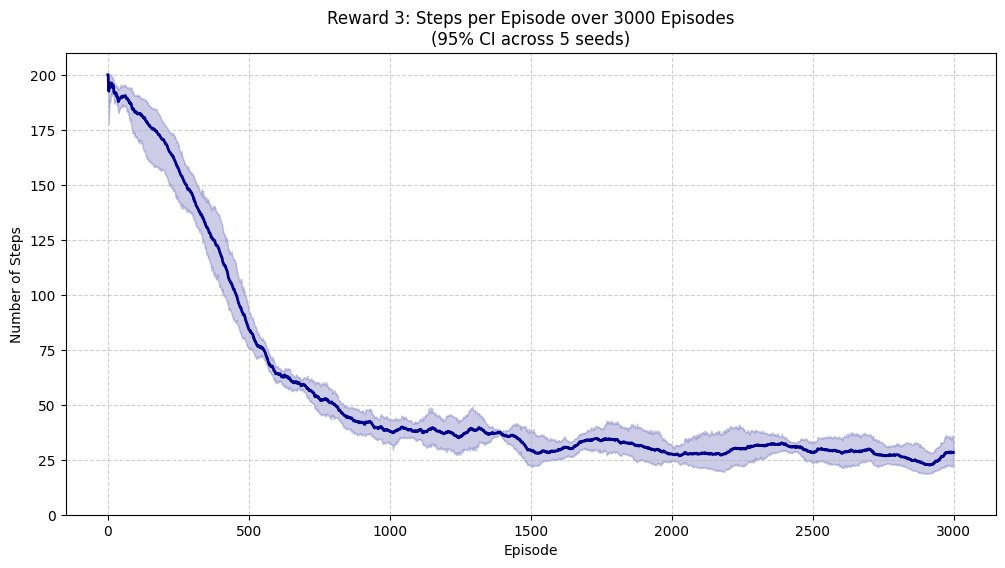

In [ ]:
print("--- Phase 2: Extended Training for 3000 Episodes ---")

RESULTS_3K_FILE = "results_reward3_3000_eps.csv"
AGENT_3K_FILE = "reward3_agent_seed2_3000.pkl"

NUM_EPISODES = 3000

agent2_3k = None

if os.path.exists(RESULTS_3K_FILE):
    print(f"Loading existing results from {RESULTS_3K_FILE}...")
    df_3k = pd.read_csv(RESULTS_3K_FILE)

    if os.path.exists(AGENT_3K_FILE):
        with open(AGENT_3K_FILE, "rb") as f:
            agent2_3k = pickle.load(f)
        print("Loaded saved second agent!")
    else:
        print("Agent file missing - retraining ONLY the second agent...")
        agent2_3k, _, _, _, _ = run_universal_training(
            reward_type="reward3",
            reward_params=params_r3,
            use_ps=True,
            episodes=NUM_EPISODES,
            seed=SEEDS[1],
            desc=f"Rebuilding Agent {SEEDS[1]}"
        )

        with open(AGENT_3K_FILE, "wb") as f:
            pickle.dump(agent2_3k, f)
        print("Saved second agent!")

else:
    print("Starting 3000-episode training across all seeds...")
    all_3k_results = []

    for seed in SEEDS:
        agent, _, steps, _, _ = run_universal_training(
            reward_type="reward3",
            reward_params=params_r3,
            use_ps=True,
            episodes=NUM_EPISODES,
            seed=seed,
            desc=f"3K Training (Seed {seed})"
        )

        if seed == SEEDS[1]:
            agent2_3k = agent
            with open(AGENT_3K_FILE, "wb") as f:
                pickle.dump(agent2_3k, f)
            print("Saved second agent!")

        for ep in range(NUM_EPISODES):
            all_3k_results.append({
                "Seed": seed,
                "Episode": ep,
                "Steps": steps[ep]
            })

    df_3k = pd.DataFrame(all_3k_results)
    df_3k.to_csv(RESULTS_3K_FILE, index=False)
    print(f"Results saved to {RESULTS_3K_FILE}")

# --- Plotting Phase 2 ---
WINDOW_SIZE = 200
df_3k['Smoothed_Steps'] = df_3k.groupby('Seed')['Steps'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_3k,
    x="Episode",
    y="Smoothed_Steps",
    errorbar=("ci", 95),
    linewidth=2,
    color="darkblue"
)
plt.title(f"Reward 3: Steps per Episode over 3000 Episodes\n(95% CI across {len(SEEDS)} seeds)")
plt.xlabel("Episode")
plt.ylabel("Number of Steps")
plt.ylim(0, 210)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print("Generating Phase 1 GIF (500 Episodes - Failure Illusion)...")
record_gif_from_trained_agent(
    agent=agents_500[1],
    config_name="Reward 3 (500 Eps)",
    reward_type="reward3",
    params=params_r3,
    filename="reward3_500_episodes_failure.gif",
    test_seed=100
)

print("\nGenerating Phase 2 GIF (3000 Episodes - Success)...")
record_gif_from_trained_agent(
    agent=agent2_3k,
    config_name="Reward 3 (3000 Eps)",
    reward_type="reward3",
    params=params_r3,
    filename="reward3_3000_episodes_success.gif",
    test_seed=100
)

Generating Phase 1 GIF (500 Episodes - Failure Illusion)...
Recording GIF for: Reward 3 (500 Eps)...
Done! Saved 'reward3_500_episodes_failure.gif' (Episode finished in 200 steps).

Generating Phase 2 GIF (3000 Episodes - Success)...
Recording GIF for: Reward 3 (3000 Eps)...
Done! Saved 'reward3_3000_episodes_success.gif' (Episode finished in 14 steps).






Reward 4 investigation


In [ ]:
print("--- Phase 1: Training Reward 4 for 500 Episodes (5 Seeds) ---")

params_r4 = {"dropoff": 60.0, "pickup": 15.0, "illegal": -25.0, "closer": 0.5, "further": -2.0, "neutral": -1.0}
SEEDS = [42, 123, 777, 999, 2024]
agents_r4_500 = []

for seed in SEEDS:
    agent, _, _, _, _ = run_universal_training(
        reward_type="reward4",
        reward_params=params_r4,
        use_ps=True,
        episodes=500,
        seed=seed,
        desc=f"Seed {seed}"
    )
    agents_r4_500.append(agent)

print("\n--- Testing Phase 1 Agents (Reward 4) ---")
# 1. Test strictly greedy (epsilon = 0.0)
_ = evaluate_multiple_agents(agents_r4_500, "Taxi-v4", "reward4", params_r4, num_episodes=100, epsilon=0.0)

# 2. Test with exploration (epsilon = 0.1) on the EXACT SAME AGENTS
_ = evaluate_multiple_agents(agents_r4_500, "Taxi-v4", "reward4", params_r4, num_episodes=100, epsilon=0.1)

--- Phase 1: Training Reward 4 for 500 Episodes (5 Seeds) ---


Seed 2024 (Seed 2024): 100%|██████████| 500/500 [00:24<00:00, 20.23it/s]



--- Testing Phase 1 Agents (Reward 4) ---

Evaluating 5 agents over 100 episodes each (ε=0.0)...
--- Evaluation Complete ---
Epsilon used: 0.0
Average Success Rate across all seeds: 27.80%
Average Steps per Episode across all seeds: 147.45

Evaluating 5 agents over 100 episodes each (ε=0.1)...
--- Evaluation Complete ---
Epsilon used: 0.1
Average Success Rate across all seeds: 37.60%
Average Steps per Episode across all seeds: 137.31


--- Phase 2: Extended Training for 3000 Episodes (Reward 4) ---
Loading existing results from results_reward4_3000_eps.csv...


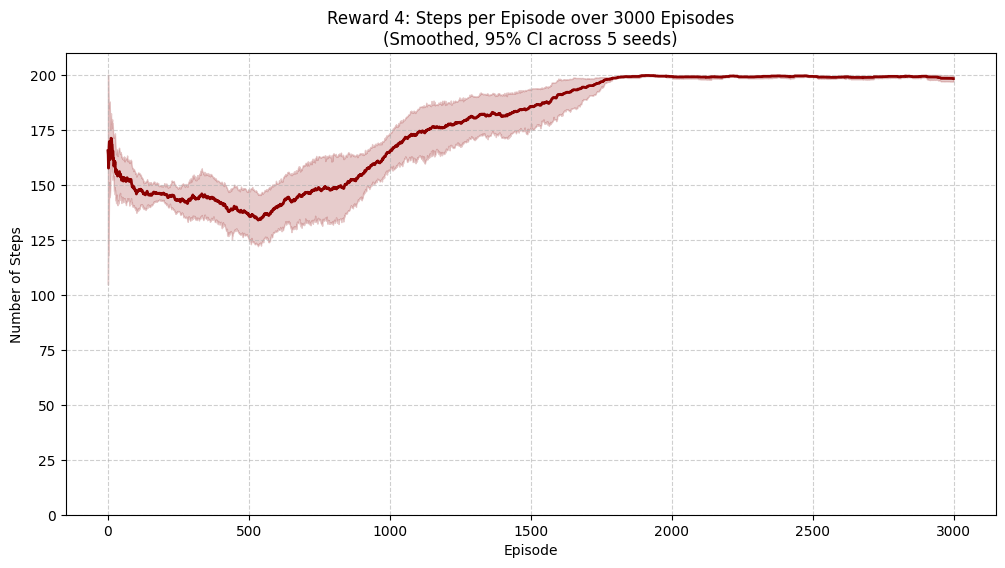

In [ ]:
print("--- Phase 2: Extended Training for 3000 Episodes (Reward 4) ---")

params_r4 = {"dropoff": 60.0, "pickup": 15.0, "illegal": -25.0, "closer": 0.5, "further": -2.0, "neutral": -1.0}

RESULTS_R4_3K_FILE = "results_reward4_3000_eps.csv"
NUM_EPISODES = 3000
agents_r4_3k = []

if os.path.exists(RESULTS_R4_3K_FILE):
    print(f"Loading existing results from {RESULTS_R4_3K_FILE}...")
    df_r4_3k = pd.read_csv(RESULTS_R4_3K_FILE)

else:

    print("Starting 3000-episode training across all seeds...")
    all_r4_3k_results = []

    for seed in SEEDS:

        agent, _, steps, _, _ = run_universal_training(
            reward_type="reward4",
            reward_params=params_r4,
            use_ps=True,
            episodes=NUM_EPISODES,
            seed=seed,
            desc=f"3K Training (Seed {seed})"
        )

        for ep in range(NUM_EPISODES):
            all_r4_3k_results.append({
                "Seed": seed,
                "Episode": ep,
                "Steps": steps[ep]
            })

        del agent
        gc.collect()

    df_r4_3k = pd.DataFrame(all_r4_3k_results)
    df_r4_3k.to_csv(RESULTS_R4_3K_FILE, index=False)

    print(f"Results saved to {RESULTS_R4_3K_FILE}")

# --- Plotting Phase 2 ---
WINDOW_SIZE = 200
df_r4_3k['Smoothed_Steps'] = df_r4_3k.groupby('Seed')['Steps'].transform(
    lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_r4_3k,
    x="Episode",
    y="Smoothed_Steps",
    errorbar=("ci", 95),
    linewidth=2,
    color="darkred"
)
plt.title(f"Reward 4: Steps per Episode over 3000 Episodes\n(Smoothed, 95% CI across {len(SEEDS)} seeds)")
plt.xlabel("Episode")
plt.ylabel("Number of Steps")
plt.ylim(0, 210)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
print("===== MAX Q PER SEED (500 Episodes) =====\n")

max_values = []
for seed, agent in zip(SEEDS, agents_r4_500):
    q_max = np.max(agent.q_table)
    max_values.append(q_max)
    print(f"Seed {seed}: max Q = {q_max:.2f}")

print("\n===== SUMMARY =====")
print(f"Average max Q: {np.mean(max_values):.2f}")
print(f"Largest Q found: {np.max(max_values):.2f}\n")

avg_q_table = np.mean([agent.q_table for agent in agents_r4_500], axis=0)

temp_env = gym.make("Taxi-v4")

print("===== TOP 20 AVERAGE Q VALUES (ACROSS ALL SEEDS - 500 Eps) =====\n")
flat_idx = np.argsort(avg_q_table.flatten())[::-1]

for idx in flat_idx[:20]:
    s, a = np.unravel_index(idx, avg_q_table.shape)
    value = avg_q_table[s, a]
    decoded = temp_env.unwrapped.decode(s)
    print(f"State={s:3d} | Action={a} | Avg_Q={value:.2f} | {decoded}")

# --- Gap & Loop Analysis ---
from collections import Counter
loop_states = Counter()
temp_env.reset()

for agent in agents_r4_500:
    for state in range(agent.state_space_size):
        best_action = np.argmax(agent.q_table[state])
        temp_env.unwrapped.s = state
        next_state, _, _, _, _ = temp_env.step(best_action)
        if next_state == state:
            loop_states[state] += 1

problematic_states = [s for s, count in loop_states.items() if count >= 3]
print("\nProblematic states (Looping):", len(problematic_states))

def q_gap(q_values):
    sorted_q = np.sort(q_values)
    return sorted_q[-1] - sorted_q[-2]

problematic_gaps = []
normal_gaps = []

for agent in agents_r4_500:
    for state in range(agent.state_space_size):
        gap = q_gap(agent.q_table[state])
        if state in problematic_states:
            problematic_gaps.append(gap)
        else:
            normal_gaps.append(gap)

print("\n===== GAP ANALYSIS =====")
if problematic_gaps:
    print(f"Problematic states average gap: {np.mean(problematic_gaps):.2f}")
print(f"Normal states average gap: {np.mean(normal_gaps):.2f}")

===== MAX Q PER SEED (500 Episodes) =====

Seed 42: max Q = 308.48
Seed 123: max Q = 291.89
Seed 777: max Q = 322.75
Seed 999: max Q = 290.73
Seed 2024: max Q = 268.58

===== SUMMARY =====
Average max Q: 296.49
Largest Q found: 322.75

===== TOP 20 AVERAGE Q VALUES (ACROSS ALL SEEDS - 500 Eps) =====

State=411 | Action=0 | Avg_Q=272.84 | (np.int64(4), np.int64(0), np.int64(2), np.int64(3))
State=411 | Action=2 | Avg_Q=270.75 | (np.int64(4), np.int64(0), np.int64(2), np.int64(3))
State=419 | Action=1 | Avg_Q=265.03 | (np.int64(4), np.int64(0), np.int64(4), np.int64(3))
State=319 | Action=3 | Avg_Q=264.50 | (np.int64(3), np.int64(0), np.int64(4), np.int64(3))
State=419 | Action=3 | Avg_Q=262.77 | (np.int64(4), np.int64(0), np.int64(4), np.int64(3))
State=319 | Action=2 | Avg_Q=262.11 | (np.int64(3), np.int64(0), np.int64(4), np.int64(3))
State=319 | Action=0 | Avg_Q=261.72 | (np.int64(3), np.int64(0), np.int64(4), np.int64(3))
State=419 | Action=0 | Avg_Q=259.98 | (np.int64(4), np.int64(

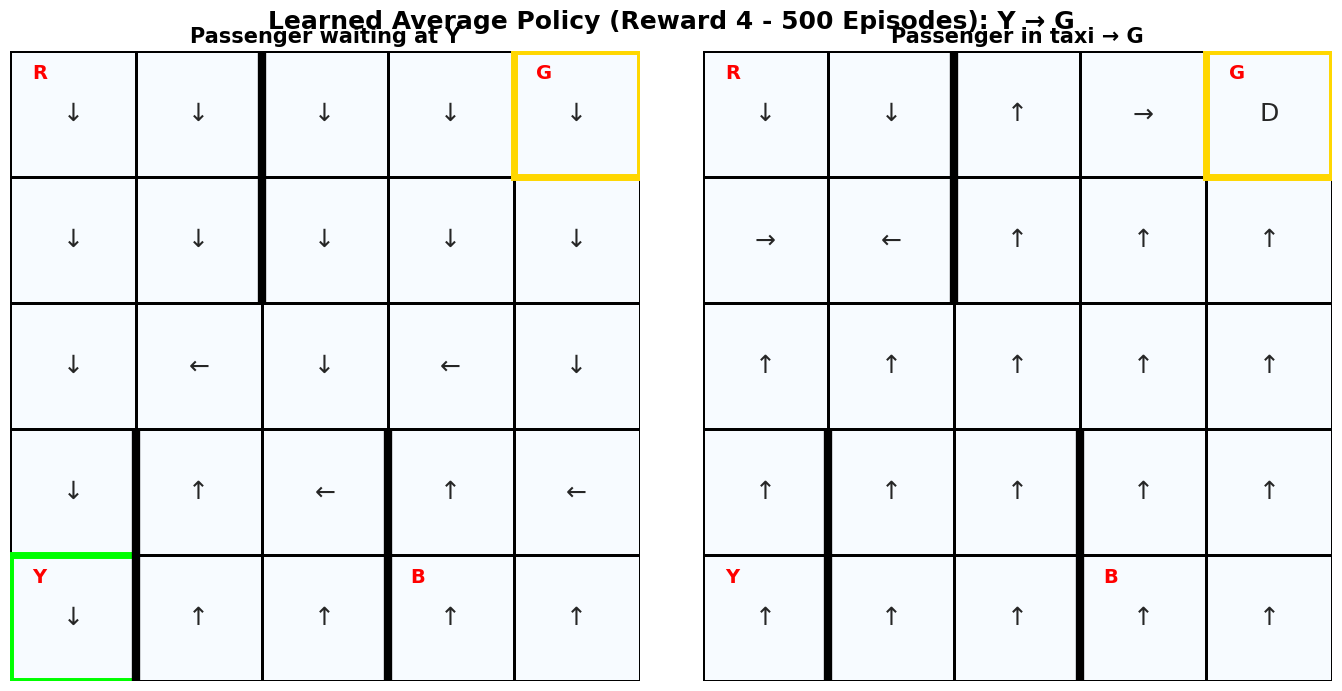

In [ ]:
policy = np.argmax(avg_q_table, axis=1)

action_symbols = {
    0: "↓", 1: "↑", 2: "→", 3: "←", 4: "P", 5: "D"
}

locations = {
    "R": (0, 0), "G": (0, 4), "Y": (4, 0), "B": (4, 3)
}

configs = [
    (2, 1, "Passenger waiting at Y"),
    (4, 1, "Passenger in taxi → G")
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (passenger, destination, title) in zip(axes, configs):
    grid = np.zeros((5, 5))
    labels = np.empty((5, 5), dtype=object)

    for r in range(5):
        for c in range(5):
            state = temp_env.unwrapped.encode(r, c, passenger, destination)
            labels[r, c] = action_symbols[policy[state]]

    sns.heatmap(
        grid, annot=labels, fmt="", cmap="Blues", cbar=False,
        square=True, linewidths=1, linecolor="black", ax=ax,
        annot_kws={"size":18}
    )

    for label, (r, c) in locations.items():
        ax.text(c + 0.18, r + 0.22, label, color="red", fontsize=14, fontweight="bold")

    walls = [(0, 1), (1, 1), (3, 0), (4, 0), (3, 2), (4, 2)]

    for row, boundary in walls:
        ax.plot(
            [boundary + 1, boundary + 1], [row, row + 1],
            color="black", linewidth=6, solid_capstyle="butt"
        )

    if passenger == 2:
        ax.add_patch(plt.Rectangle((0, 4), 1, 1, fill=False, edgecolor="lime", linewidth=5))
    ax.add_patch(plt.Rectangle((4, 0), 1, 1, fill=False, edgecolor="gold", linewidth=5))

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Learned Average Policy (Reward 4 - 500 Episodes): Y → G", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

Parameter Sweeps - epsilon

In [ ]:
def run_epsilon_sweep_learning_curves(
    epsilon_values=[0.01, 0.05, 0.1, 0.2, 0.4],
    episodes=500,
    seeds=[42, 123, 777, 999, 2024],
    alpha=0.1,
    gamma=0.99,
    planning_steps=5,
    reward_type="base",
    reward_params=None
):
    if reward_params is None:
        reward_params = {}
    # Algorithms compared in this sweep
    component_setups = [
        {"name": "SARSA", "use_ps": False, "use_kernel": False},
        {"name": "SARSA + PS", "use_ps": True, "use_kernel": False}
    ]

    all_results = []

    for epsilon in epsilon_values:
        print(f"\nRunning epsilon = {epsilon}")
        # Run each algorithm with the current epsilon
        for setup in component_setups:
            print(f"Algorithm: {setup['name']}")

            for seed in seeds:
                _, rewards, steps, errors, successes = run_universal_training(
                    reward_type=reward_type,
                    reward_params=reward_params,
                    use_ps=setup["use_ps"],
                    use_kernel=setup["use_kernel"],
                    episodes=episodes,
                    seed=seed,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon=epsilon,
                    planning_steps=planning_steps,
                    desc=f"{setup['name']} | epsilon={epsilon}"
                )

                for ep in range(episodes):
                    all_results.append({
                        "Epsilon": epsilon,
                        "Algorithm": setup["name"],
                        "Seed": seed,
                        "Episode": ep,
                        "Reward": rewards[ep],
                        "Steps": steps[ep],
                        "Errors": errors[ep],
                        "Success": successes[ep]
                    })

    df_epsilon = pd.DataFrame(all_results)
    return df_epsilon

In [ ]:
EXPERIMENT_NAME = "epsilon_sweep_learning_curves"
RESULTS_FILE = f"results_{EXPERIMENT_NAME}.csv"

if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}...")
    df_epsilon = pd.read_csv(RESULTS_FILE)

else:
    print(f"No existing results found. Starting training for {EXPERIMENT_NAME}...")

    df_epsilon = run_epsilon_sweep_learning_curves(
        epsilon_values=[0.01, 0.05, 0.1, 0.2, 0.4],
        episodes=EPISODES,
        seeds=SEEDS,
        alpha=0.1,
        gamma=0.99,
        planning_steps=5,
        reward_type="base",
        reward_params={}
    )

    df_epsilon.to_csv(RESULTS_FILE, index=False)
    print(f"Training finished! Results saved to {RESULTS_FILE}")

Loading existing results from results_epsilon_sweep_learning_curves.csv...


In [ ]:
WINDOW_SIZE = 50

df_epsilon["Smoothed_Reward"] = (
    df_epsilon
    .groupby(["Epsilon", "Algorithm", "Seed"])["Reward"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_epsilon["Smoothed_Steps"] = (
    df_epsilon
    .groupby(["Epsilon", "Algorithm", "Seed"])["Steps"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_epsilon["Smoothed_Errors"] = (
    df_epsilon
    .groupby(["Epsilon", "Algorithm", "Seed"])["Errors"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_epsilon["Smoothed_Success"] = (
    df_epsilon
    .groupby(["Epsilon", "Algorithm", "Seed"])["Success"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

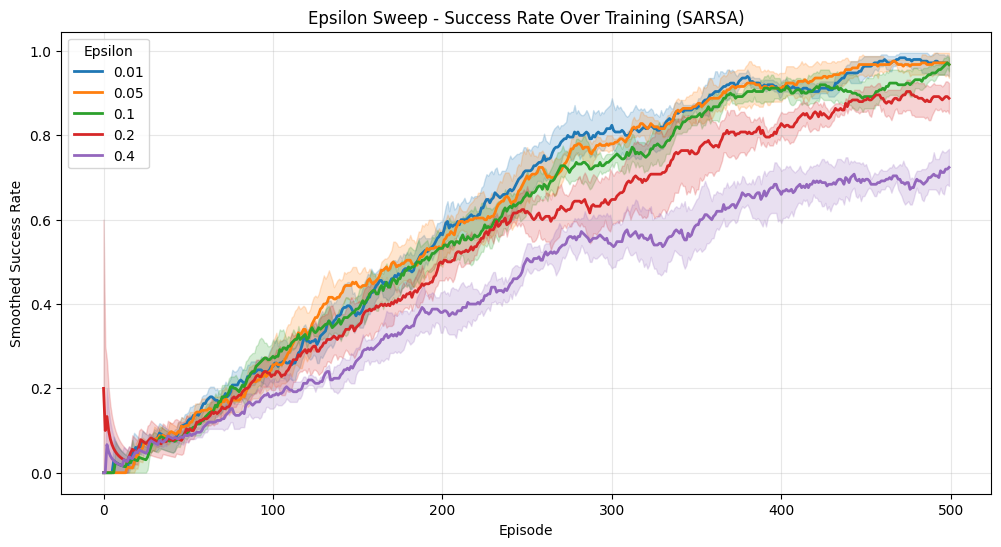

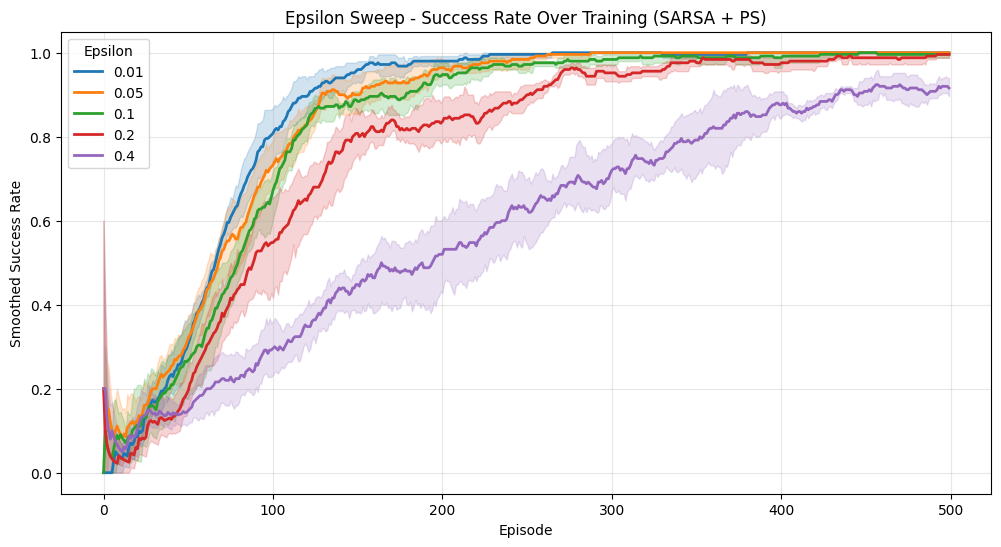

In [ ]:
epsilon_palette = {
    0.01: "#1f77b4",  # blue
    0.05: "#ff7f0e",  # orange
    0.1:  "#2ca02c",  # green
    0.2:  "#d62728",  # red
    0.4:  "#9467bd"   # purple
}

for algorithm in df_epsilon["Algorithm"].unique():

    df_plot = df_epsilon[df_epsilon["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Success",
        hue="Epsilon",
        hue_order=[0.01, 0.05, 0.1, 0.2, 0.4],
        palette=epsilon_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Epsilon Sweep - Success Rate Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Success Rate")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Epsilon")
    plt.show()

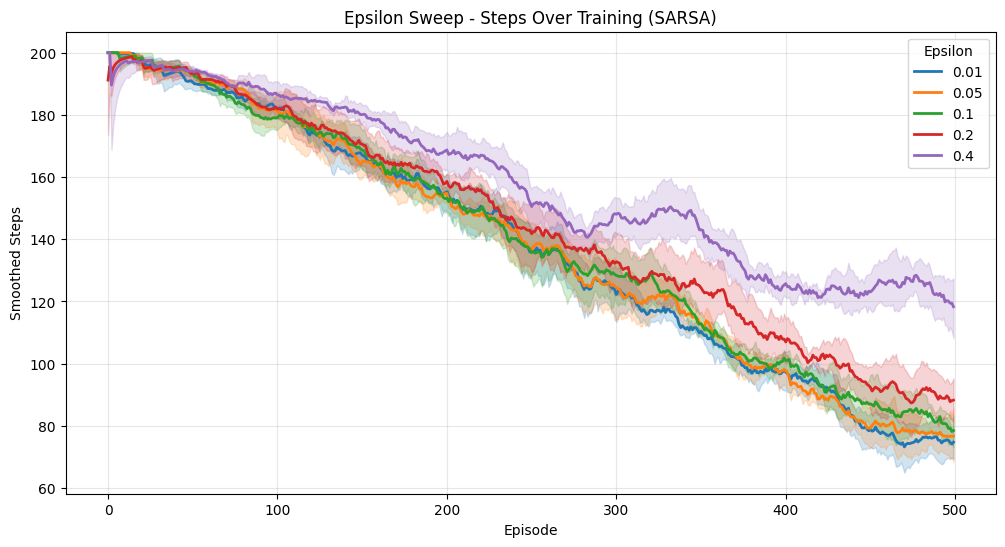

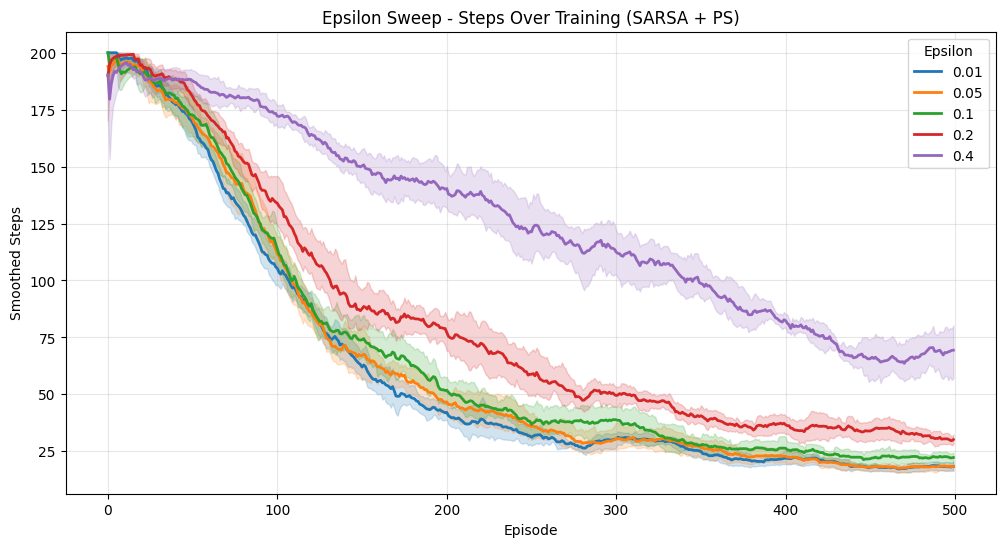

In [ ]:
epsilon_palette = {
    0.01: "#1f77b4",  # blue
    0.05: "#ff7f0e",  # orange
    0.1:  "#2ca02c",  # green
    0.2:  "#d62728",  # red
    0.4:  "#9467bd"   # purple
}

for algorithm in df_epsilon["Algorithm"].unique():

    df_plot = df_epsilon[df_epsilon["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Steps",
        hue="Epsilon",
        hue_order=[0.01, 0.05, 0.1, 0.2, 0.4],
        palette=epsilon_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Epsilon Sweep - Steps Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Steps")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Epsilon")
    plt.show()

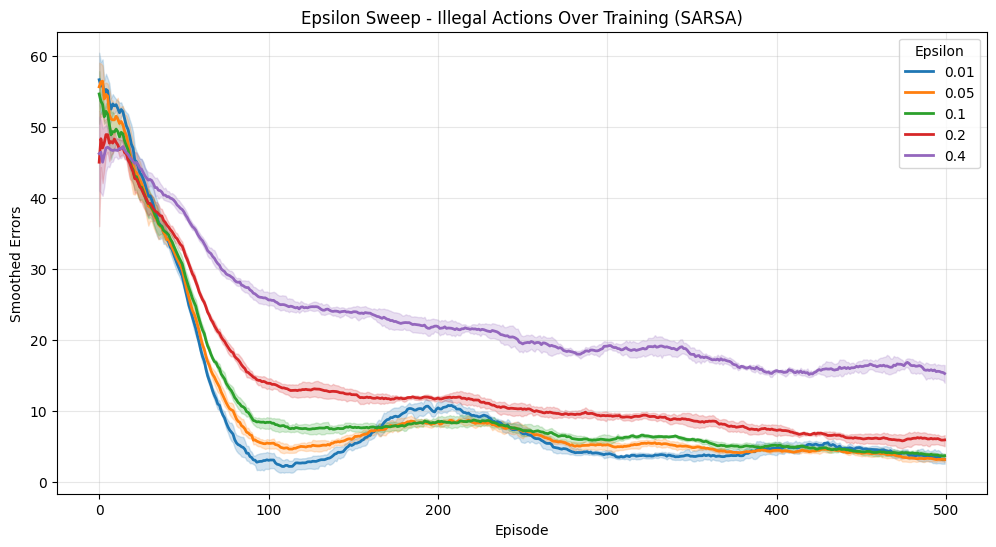

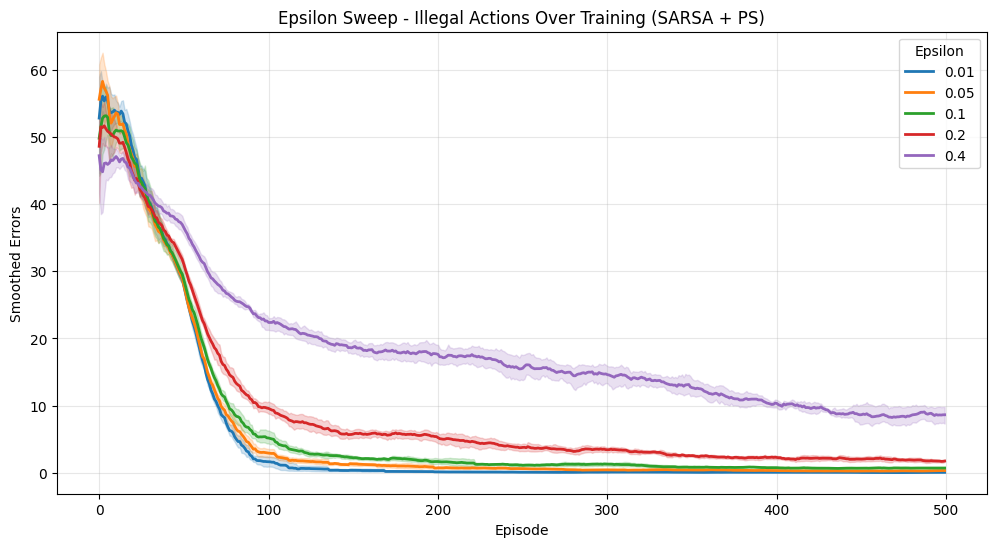

In [ ]:
epsilon_palette = {
    0.01: "#1f77b4",  # blue
    0.05: "#ff7f0e",  # orange
    0.1:  "#2ca02c",  # green
    0.2:  "#d62728",  # red
    0.4:  "#9467bd"   # purple
}

for algorithm in df_epsilon["Algorithm"].unique():

    df_plot = df_epsilon[df_epsilon["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Errors",
        hue="Epsilon",
        hue_order=[0.01, 0.05, 0.1, 0.2, 0.4],
        palette=epsilon_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Epsilon Sweep - Illegal Actions Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Errors")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Epsilon")
    plt.show()

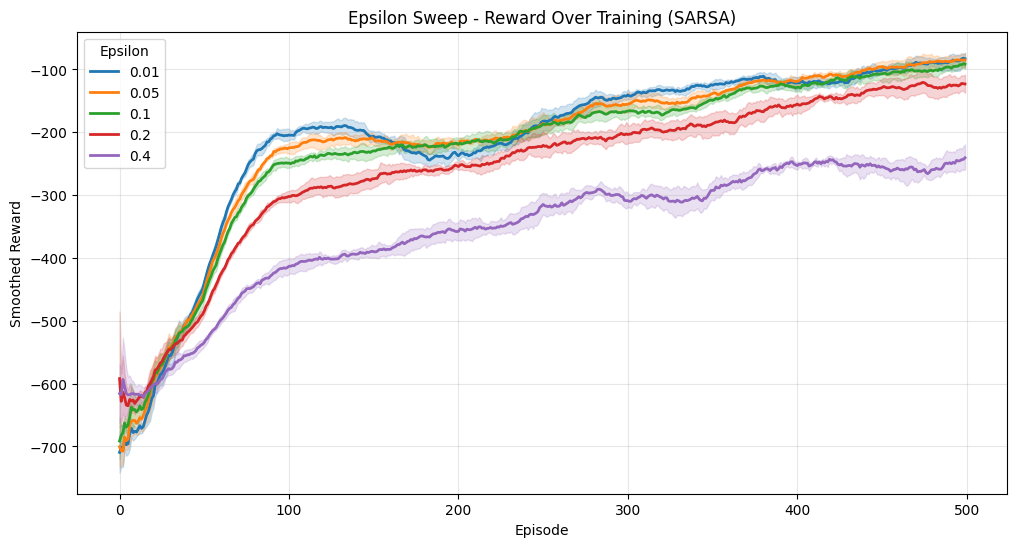

In [ ]:
epsilon_palette = {
    0.01: "#1f77b4",  # blue
    0.05: "#ff7f0e",  # orange
    0.1:  "#2ca02c",  # green
    0.2:  "#d62728",  # red
    0.4:  "#9467bd"   # purple
}

for algorithm in df_epsilon["Algorithm"].unique():

    df_plot = df_epsilon[df_epsilon["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Reward",
        hue="Epsilon",
        hue_order=[0.01, 0.05, 0.1, 0.2, 0.4],
        palette=epsilon_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Epsilon Sweep - Reward Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Reward")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Epsilon")
    plt.show()

Parameter Sweeps - n

In [ ]:
def run_planning_steps_sweep_learning_curves(
    planning_steps_values=[1, 3, 5, 10, 20],
    episodes=500,
    seeds=[42, 123, 777, 999, 2024],
    alpha=0.1,
    gamma=0.99,
    epsilon=0.1,
    c=0.5,
    beta=4,
    reward_type="base",
    reward_params=None
):
    if reward_params is None:
        reward_params = {}
    # Algorithms compared in this sweep
    component_setups = [
        {"name": "SARSA + PS", "use_ps": True, "use_kernel": False},
        {"name": "SARSA + PS + Kernel", "use_ps": True, "use_kernel": True}
    ]

    all_results = []

    for planning_steps in planning_steps_values:
        print(f"\nRunning planning_steps = {planning_steps}")
        # Run each algorithm with the current n
        for setup in component_setups:
            print(f"Algorithm: {setup['name']}")

            for seed in seeds:
                _, rewards, steps, errors, successes = run_universal_training(
                    reward_type=reward_type,
                    reward_params=reward_params,
                    use_ps=setup["use_ps"],
                    use_kernel=setup["use_kernel"],
                    episodes=episodes,
                    seed=seed,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon=epsilon,
                    planning_steps=planning_steps,
                    c=c,
                    beta=beta,
                    desc=f"{setup['name']} | n={planning_steps}"
                )

                for ep in range(episodes):
                    all_results.append({
                        "Planning_Steps": planning_steps,
                        "Algorithm": setup["name"],
                        "Seed": seed,
                        "Episode": ep,
                        "Reward": rewards[ep],
                        "Steps": steps[ep],
                        "Errors": errors[ep],
                        "Success": successes[ep]
                    })

    df_n = pd.DataFrame(all_results)
    return df_n

In [ ]:
EXPERIMENT_NAME = "planning_steps_sweep_learning_curves"
RESULTS_FILE = f"results_{EXPERIMENT_NAME}.csv"

if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}...")
    df_n = pd.read_csv(RESULTS_FILE)

else:
    print(f"No existing results found. Starting training for {EXPERIMENT_NAME}...")

    df_n = run_planning_steps_sweep_learning_curves(
        planning_steps_values=[1, 3, 5, 10, 20],
        episodes=EPISODES,
        seeds=SEEDS,
        alpha=0.1,
        gamma=0.99,
        epsilon=0.1,
        c=0.5,
        beta=4,
        reward_type="base",
        reward_params={}
    )

    df_n.to_csv(RESULTS_FILE, index=False)
    print(f"Training finished! Results saved to {RESULTS_FILE}")

No existing results found. Starting training for planning_steps_sweep_learning_curves...

Running planning_steps = 1
Algorithm: SARSA + PS


SARSA + PS | n=1 (Seed 42): 100%|██████████| 500/500 [00:04<00:00, 109.41it/s]
SARSA + PS | n=1 (Seed 123): 100%|██████████| 500/500 [00:07<00:00, 69.62it/s]
SARSA + PS | n=1 (Seed 777): 100%|██████████| 500/500 [00:05<00:00, 97.69it/s] 
SARSA + PS | n=1 (Seed 999): 100%|██████████| 500/500 [00:05<00:00, 97.08it/s] 
SARSA + PS | n=1 (Seed 2024): 100%|██████████| 500/500 [00:07<00:00, 67.29it/s] 


Algorithm: SARSA + PS + Kernel


SARSA + PS + Kernel | n=1 (Seed 42): 100%|██████████| 500/500 [01:07<00:00,  7.41it/s]
SARSA + PS + Kernel | n=1 (Seed 123): 100%|██████████| 500/500 [01:07<00:00,  7.45it/s]
SARSA + PS + Kernel | n=1 (Seed 777): 100%|██████████| 500/500 [01:07<00:00,  7.37it/s]
SARSA + PS + Kernel | n=1 (Seed 999): 100%|██████████| 500/500 [01:06<00:00,  7.48it/s]
SARSA + PS + Kernel | n=1 (Seed 2024): 100%|██████████| 500/500 [01:07<00:00,  7.35it/s]



Running planning_steps = 3
Algorithm: SARSA + PS


...


Running planning_steps = 20
Algorithm: SARSA + PS


SARSA + PS | n=20 (Seed 42): 100%|██████████| 500/500 [00:22<00:00, 22.34it/s]
SARSA + PS | n=20 (Seed 123): 100%|██████████| 500/500 [00:25<00:00, 19.40it/s]
SARSA + PS | n=20 (Seed 777): 100%|██████████| 500/500 [00:25<00:00, 19.44it/s]
SARSA + PS | n=20 (Seed 999): 100%|██████████| 500/500 [00:25<00:00, 19.29it/s]
SARSA + PS | n=20 (Seed 2024): 100%|██████████| 500/500 [00:25<00:00, 19.41it/s]


Algorithm: SARSA + PS + Kernel


SARSA + PS + Kernel | n=20 (Seed 42): 100%|██████████| 500/500 [00:53<00:00,  9.33it/s]
SARSA + PS + Kernel | n=20 (Seed 123): 100%|██████████| 500/500 [00:49<00:00, 10.14it/s]
SARSA + PS + Kernel | n=20 (Seed 777): 100%|██████████| 500/500 [00:48<00:00, 10.30it/s]
SARSA + PS + Kernel | n=20 (Seed 999): 100%|██████████| 500/500 [00:49<00:00, 10.06it/s]
SARSA + PS + Kernel | n=20 (Seed 2024): 100%|██████████| 500/500 [00:57<00:00,  8.75it/s]


Training finished! Results saved to results_planning_steps_sweep_learning_curves.csv


In [ ]:
WINDOW_SIZE = 50

df_n["Smoothed_Reward"] = (
    df_n
    .groupby(["Planning_Steps", "Algorithm", "Seed"])["Reward"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_n["Smoothed_Steps"] = (
    df_n
    .groupby(["Planning_Steps", "Algorithm", "Seed"])["Steps"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_n["Smoothed_Errors"] = (
    df_n
    .groupby(["Planning_Steps", "Algorithm", "Seed"])["Errors"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

df_n["Smoothed_Success"] = (
    df_n
    .groupby(["Planning_Steps", "Algorithm", "Seed"])["Success"]
    .transform(lambda x: x.rolling(WINDOW_SIZE, min_periods=1).mean())
)

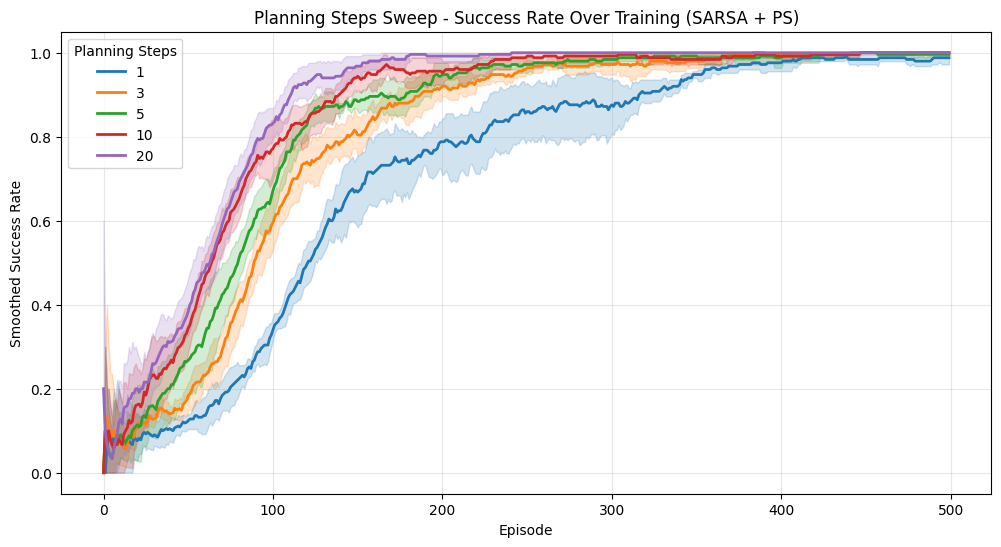

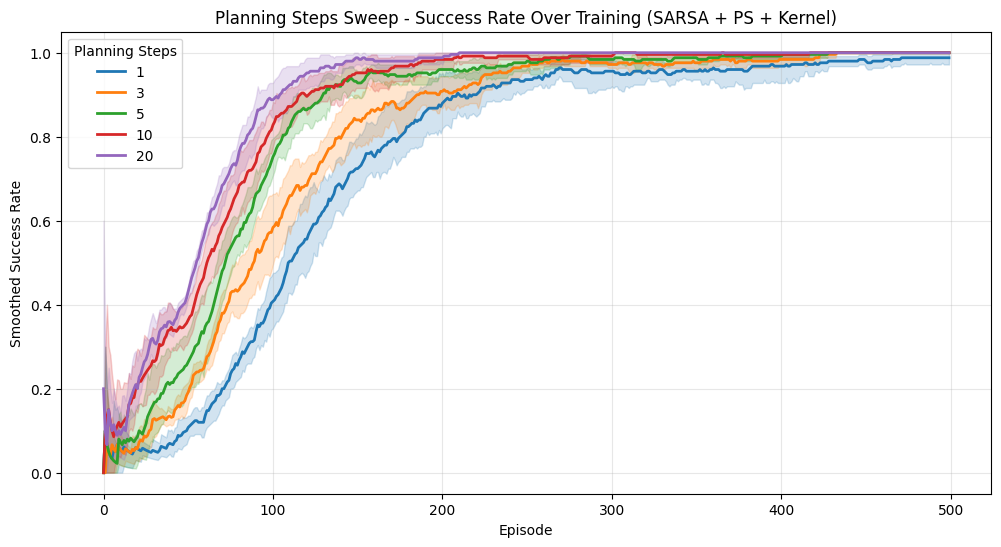

In [ ]:
planning_palette = {
    1:  "#1f77b4",  # blue
    3:  "#ff7f0e",  # orange
    5:  "#2ca02c",  # green
    10: "#d62728",  # red
    20: "#9467bd"   # purple
}

for algorithm in df_n["Algorithm"].unique():

    df_plot = df_n[df_n["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Success",
        hue="Planning_Steps",
        hue_order=[1, 3, 5, 10, 20],
        palette=planning_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Planning Steps Sweep - Success Rate Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Success Rate")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Planning Steps")
    plt.show()

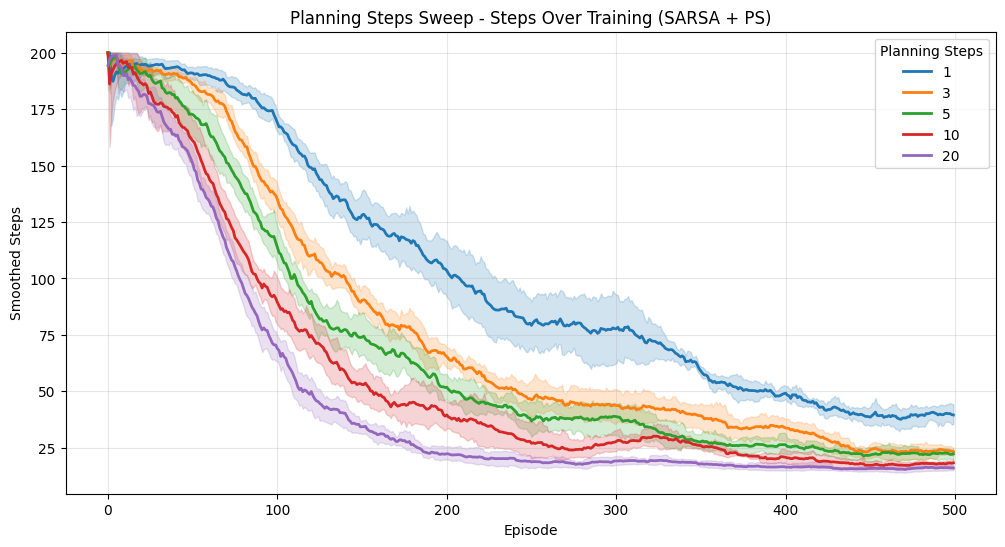

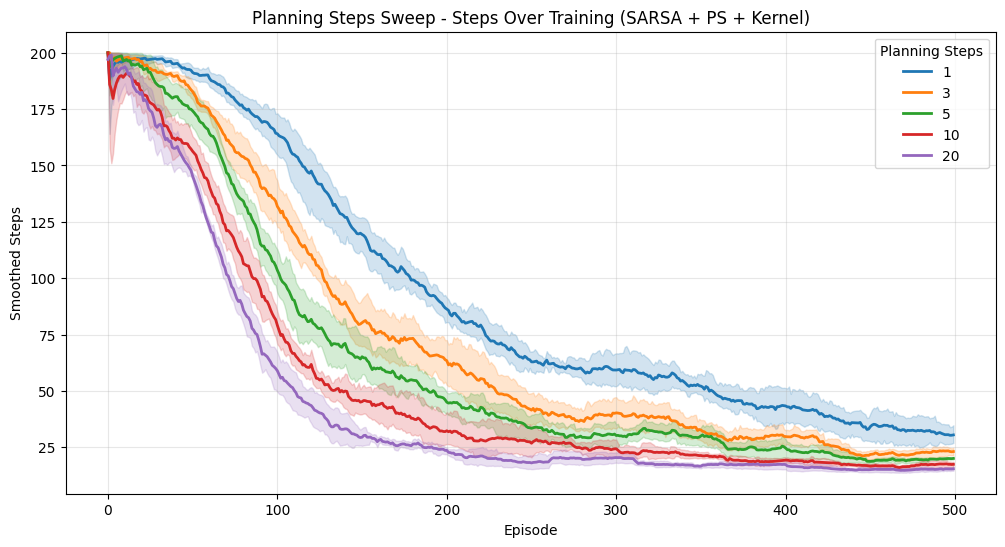

In [ ]:
planning_palette = {
    1:  "#1f77b4",  # blue
    3:  "#ff7f0e",  # orange
    5:  "#2ca02c",  # green
    10: "#d62728",  # red
    20: "#9467bd"   # purple
}

for algorithm in df_n["Algorithm"].unique():

    df_plot = df_n[df_n["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Steps",
        hue="Planning_Steps",
        hue_order=[1, 3, 5, 10, 20],
        palette=planning_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Planning Steps Sweep - Steps Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Steps")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Planning Steps")
    plt.show()

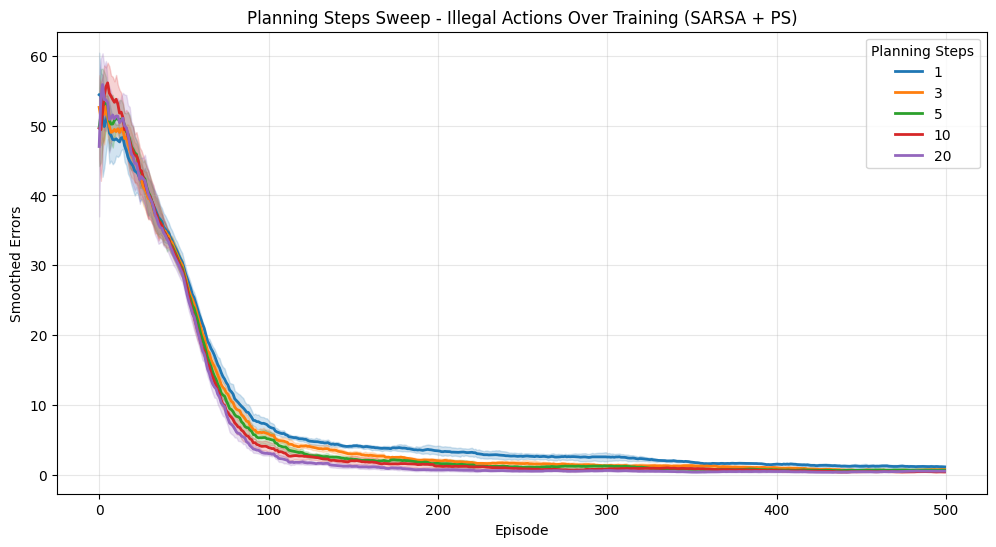

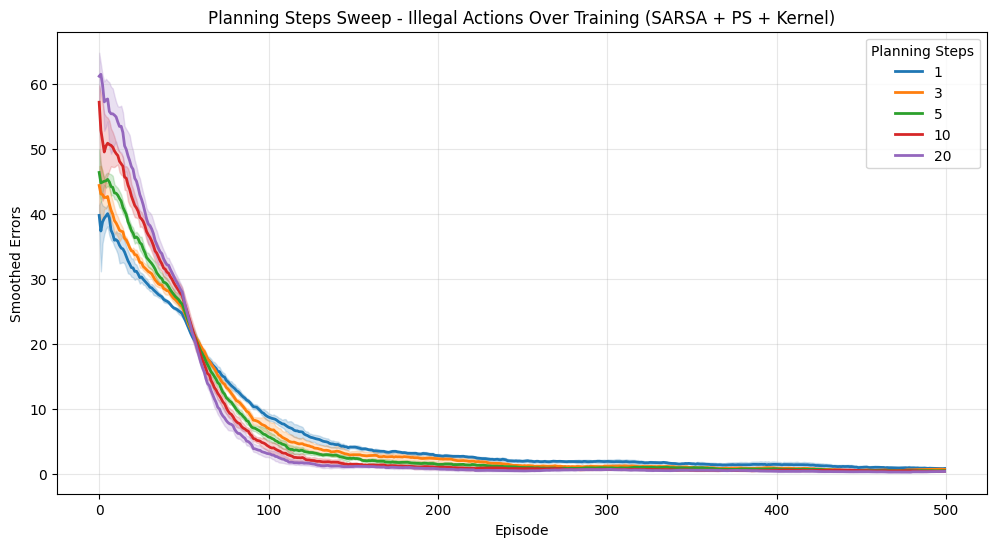

In [ ]:
planning_palette = {
    1:  "#1f77b4",  # blue
    3:  "#ff7f0e",  # orange
    5:  "#2ca02c",  # green
    10: "#d62728",  # red
    20: "#9467bd"   # purple
}

for algorithm in df_n["Algorithm"].unique():

    df_plot = df_n[df_n["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Errors",
        hue="Planning_Steps",
        hue_order=[1, 3, 5, 10, 20],
        palette=planning_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Planning Steps Sweep - Illegal Actions Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Errors")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Planning Steps")
    plt.show()

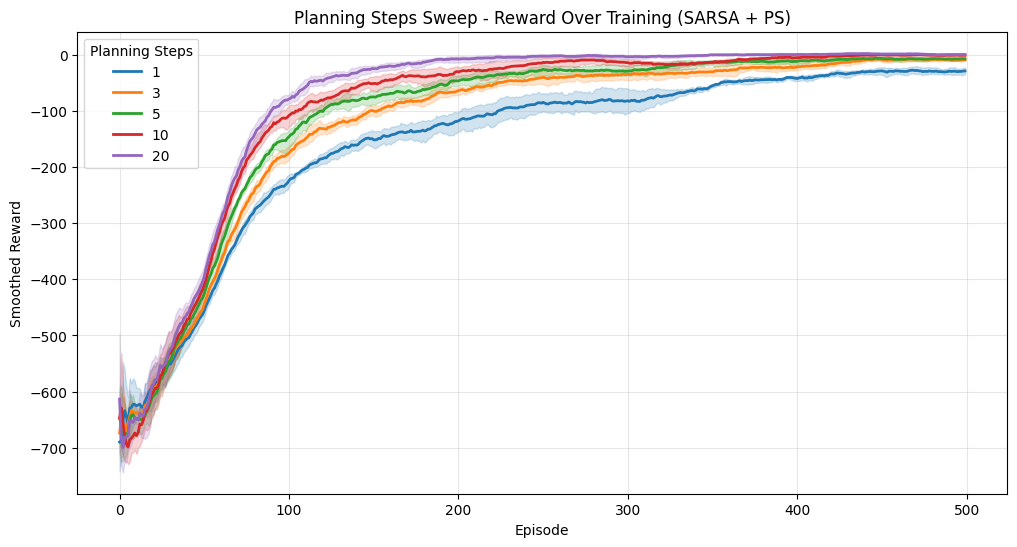

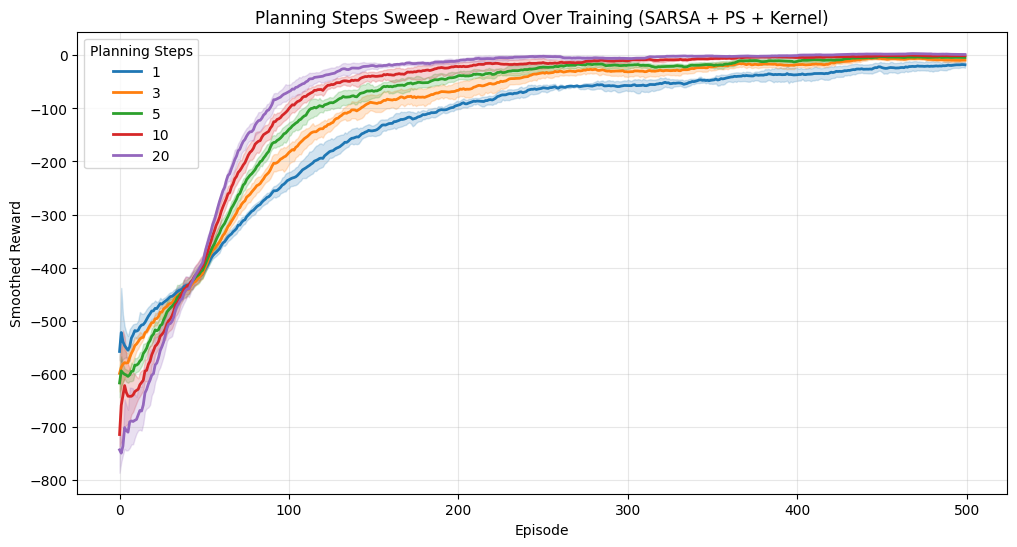

In [ ]:
planning_palette = {
    1:  "#1f77b4",  # blue
    3:  "#ff7f0e",  # orange
    5:  "#2ca02c",  # green
    10: "#d62728",  # red
    20: "#9467bd"   # purple
}

for algorithm in df_n["Algorithm"].unique():

    df_plot = df_n[df_n["Algorithm"] == algorithm]

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=df_plot,
        x="Episode",
        y="Smoothed_Reward",
        hue="Planning_Steps",
        hue_order=[1, 3, 5, 10, 20],
        palette=planning_palette,
        errorbar=("ci", 95),
        linewidth=2
    )

    plt.title(f"Planning Steps Sweep - Reward Over Training ({algorithm})")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Reward")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Planning Steps")
    plt.show()